# Decision Trees for Customer Segmentation

## Project Objective

In this notebook, we build and explain Decision Tree classification models for a customer segmentation problem.

The business goal is to predict the correct customer segment based on customer demographic and behavioral attributes. This type of model can support BI and marketing analytics teams by helping them understand which customer characteristics separate different customer groups.

## Learning Goals

By the end of this notebook, we will be able to:

1. Understand how Decision Trees classify customers using feature-based yes/no rules.
2. Train a baseline `DecisionTreeClassifier` with limited tree depth.
3. Compare training and test accuracy to detect overfitting.
4. Visualize the Decision Tree and explain the root feature in business terms.
5. Compare Gini impurity and Entropy as split criteria.
6. Apply pruning techniques such as `min_samples_leaf` and cost-complexity pruning.
7. Extract and interpret feature importances.
8. Compare a standard Decision Tree with an Oblique Decision Tree.
9. Use SHAP to explain global feature impact and one misclassified customer.

## Dataset

We use a customer segmentation dataset from Kaggle. Each customer belongs to one of several predefined customer segments. The model learns patterns from historical customer records and predicts the segment for unseen customers.

## Business Context

Customer segmentation helps companies personalize marketing campaigns, improve sales targeting, design better offers, and understand customer behavior. A Decision Tree is useful here because its logic can be translated into simple business rules.

In [1]:
# ============================================================
# Code Cell 1: Download Customer Segmentation Dataset from Kaggle
# ============================================================
# Purpose:
# - Install/check Kaggle package
# - Check Kaggle API credentials
# - Download the selected customer segmentation dataset
# - Store files inside a clean project-relative data folder
#
# Important:
# - Do NOT paste your Kaggle token inside this notebook.
# - Keep kaggle.json outside GitHub.
# ============================================================

from pathlib import Path
import os
import sys
import subprocess

# -----------------------------
# 1. Define Kaggle dataset slug
# -----------------------------
DATASET_SLUG = "kaushiksuresh147/customer-segmentation"

# -----------------------------
# 2. Define project-relative folder
# -----------------------------
DATA_DIR = Path("data/customer_segmentation")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset folder: {DATA_DIR.resolve()}")

# -----------------------------
# 3. Check whether Kaggle package is installed
# -----------------------------
try:
    import kaggle
    print("Kaggle package is already installed.")
except Exception:
    print("Kaggle package not found. Installing kaggle package...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kaggle"],
        check=True
    )
    print("Kaggle package installed successfully.")

# -----------------------------
# 4. Check Kaggle credentials
# -----------------------------
kaggle_json_path = Path.home() / ".kaggle" / "kaggle.json"

has_kaggle_file = kaggle_json_path.exists()
has_kaggle_env = (
    bool(os.environ.get("KAGGLE_USERNAME")) 
    and bool(os.environ.get("KAGGLE_KEY"))
)

if not has_kaggle_file and not has_kaggle_env:
    print("\nKaggle credentials were not found.")
    print("Please place kaggle.json inside your ~/.kaggle/ folder.")
    print("Do NOT paste your Kaggle token inside this notebook.")
else:
    print("Kaggle credentials found.")

    # -----------------------------
    # 5. Download and unzip dataset
    # -----------------------------
    download_command = [
        "kaggle", "datasets", "download",
        "-d", DATASET_SLUG,
        "-p", str(DATA_DIR),
        "--unzip"
    ]

    print("\nDownloading dataset from Kaggle...")
    result = subprocess.run(download_command, capture_output=True, text=True)

    if result.returncode == 0:
        print("Dataset downloaded and extracted successfully.")
    else:
        print("Dataset download failed.")
        print(result.stderr)

    # -----------------------------
    # 6. List downloaded files
    # -----------------------------
    print("\nFiles available in dataset folder:")
    for file_path in DATA_DIR.iterdir():
        print(f"- {file_path.name}")

Dataset folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_7_ml/data/customer_segmentation


Kaggle package is already installed.
Kaggle credentials found.

Dataset downloaded and extracted successfully.

Files available in dataset folder:
- Test.csv
- Train.csv


In [2]:
# ============================================================
# Code Cell 2: Load Train/Test Files and Inspect Dataset Shape
# ============================================================
# Purpose:
# - Load Train.csv and Test.csv from the project-relative data folder
# - Check rows, columns, column names, and first few records
# - Confirm the target column for classification
# ============================================================

import pandas as pd
import numpy as np

# -----------------------------
# 1. Define file paths
# -----------------------------
train_path = DATA_DIR / "Train.csv"
test_path = DATA_DIR / "Test.csv"

# -----------------------------
# 2. Load files
# -----------------------------
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# -----------------------------
# 3. Basic shape check
# -----------------------------
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

# -----------------------------
# 4. Display column names
# -----------------------------
print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

# -----------------------------
# 5. Preview first rows
# -----------------------------
display(train_df.head())
display(test_df.head())

# -----------------------------
# 6. Confirm target column
# -----------------------------
target_column = "Segmentation"

if target_column in train_df.columns:
    print(f"\nTarget column found: {target_column}")
    print("\nTarget class distribution:")
    display(train_df[target_column].value_counts().sort_index())
else:
    print(f"\nTarget column '{target_column}' not found. Check column names.")

Training data shape: (8068, 11)
Test data shape: (2627, 11)

Training columns:
['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']

Test columns:
['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,A



Target column found: Segmentation

Target class distribution:


Segmentation
A    1972
B    1858
C    1970
D    2268
Name: count, dtype: int64

## 3. Data Quality Audit

Before training a Decision Tree, we first inspect the dataset quality.

A Decision Tree learns splitting rules from the input features. If the data contains missing values, duplicate records, or an imbalanced target variable, the model can learn weak or misleading rules.

In this section, we check:

- dataset size,
- duplicate rows,
- missing values,
- target class distribution,
- numerical and categorical feature columns.

This step connects to the Decision Tree theory because clean and well-understood input data helps the tree create more reliable splits.

In [3]:
# ============================================================
# Code Cell 3A: Dataset Size and Duplicate Check
# ============================================================
# Purpose:
# - Check how many rows and columns are in the training data
# - Check whether duplicate rows exist
#
# Why this matters:
# - Duplicate rows can make the model over-learn repeated records
# - Dataset size helps us understand how much data the tree can learn from
# ============================================================

# Number of rows and columns in the training dataset
num_rows, num_columns = train_df.shape

print("Training dataset overview")
print("-" * 35)
print(f"Rows: {num_rows:,}")
print(f"Columns: {num_columns:,}")

# Count duplicate rows
duplicate_count = train_df.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_count:,}")

Training dataset overview
-----------------------------------
Rows: 8,068
Columns: 11

Duplicate rows: 0


In [4]:
# ============================================================
# Code Cell 3B: Missing Values Check
# ============================================================
# Purpose:
# - Check which columns contain missing values
# - Count missing values in each column
# - Calculate missing percentage for each column
#
# Why this matters:
# - Decision Trees in sklearn cannot directly handle missing values
# - We must decide how to treat missing numeric and categorical values
# - Missing values can affect split quality and model reliability
# ============================================================

# Count missing values column by column
missing_summary = train_df.isna().sum().reset_index()

# Rename columns for readability
missing_summary.columns = ["column_name", "missing_count"]

# Calculate missing percentage
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(train_df) * 100
).round(2)

# Sort columns with highest missing values first
missing_summary = missing_summary.sort_values(
    by="missing_count",
    ascending=False
)

# Display only columns with missing values
missing_summary_with_values = missing_summary[
    missing_summary["missing_count"] > 0
]

display(missing_summary_with_values)

,column_name,missing_count,missing_percentage
6,Work_Experience,829,10.28
8,Family_Size,335,4.15
2,Ever_Married,140,1.74
5,Profession,124,1.54
4,Graduated,78,0.97
9,Var_1,76,0.94


### Data Quality Conclusion: Missing Values

The dataset contains missing values in both numerical and categorical columns.

The highest missing percentage is in `Work_Experience` with around 10.28%, followed by `Family_Size` with around 4.15%. Other missing values appear in categorical columns such as `Ever_Married`, `Profession`, `Graduated`, and `Var_1`.

This means we cannot directly train a sklearn `DecisionTreeClassifier` on the raw dataset. Before modelling, we need to handle missing values through preprocessing:

- numerical missing values will be filled using a suitable numerical strategy,
- categorical missing values will be filled using a suitable categorical strategy,
- categorical variables will later be encoded so the model can use them.

This step is important because Decision Trees create split rules from feature values. If missing values are not handled properly, the model training will fail or produce unreliable rules.

### 3.3 Target Class Distribution

Before training a classification model, we need to understand the target variable.

In this project, the target column is `Segmentation`. This is the class label that the Decision Tree will learn to predict. Since this is a multiclass classification problem, each customer belongs to one of several customer segments such as A, B, C, or D.

Checking the target distribution helps us understand whether the customer segments are balanced or imbalanced.

This connects directly to classification evaluation:

- if all segments have similar counts, accuracy is easier to interpret,
- if one segment is much larger than the others, accuracy can become misleading,
- for imbalanced classes, we must pay more attention to precision, recall, F1-score, and the confusion matrix.

In simple terms, this step checks whether the model will learn from a fair mix of customer segments or whether one segment dominates the dataset.

In [5]:
# ============================================================
# Code Cell 3C: Target Class Distribution
# ============================================================
# Purpose:
# - Check how many customers belong to each segment
# - Calculate the percentage share of each segment
#
# Why this matters:
# - Our target column is the class label the model will predict
# - If one segment is much larger than the others, accuracy can become misleading
# - For multiclass classification, we must understand class balance early
# ============================================================

# Count customers in each segment
target_distribution = (
    train_df["Segmentation"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns clearly
target_distribution.columns = ["segment", "customer_count"]

# Calculate percentage share of each segment
target_distribution["percentage"] = (
    target_distribution["customer_count"] / len(train_df) * 100
).round(2)

# Display target distribution table
display(target_distribution)

,segment,customer_count,percentage
0,A,1972,24.44
1,B,1858,23.03
2,C,1970,24.42
3,D,2268,28.11


### Target Distribution Conclusion

The target variable `Segmentation` contains four customer segments: A, B, C, and D.

The class distribution is reasonably balanced:

- Segment A: 24.44%
- Segment B: 23.03%
- Segment C: 24.42%
- Segment D: 28.11%

Segment D is slightly larger than the other classes, but the difference is not extreme. This means accuracy can still be useful, but we should not rely on accuracy alone.

For a multiclass classification problem, we will also evaluate the model using:

- confusion matrix,
- precision,
- recall,
- F1-score,
- macro average,
- weighted average.

This helps us understand not only how often the model is correct overall, but also which customer segments are easier or harder to predict.

### 3.4 Feature Type Identification

Before building a Decision Tree model, we need to separate the input columns by data type.

The dataset contains two main types of features:

1. **Numerical features**  
   These are number-based columns such as age, work experience, or family size.

2. **Categorical features**  
   These are text/category-based columns such as gender, profession, spending score, or marital status.

This step is important because sklearn models need numerical input. Numerical features can be used directly after handling missing values, but categorical features must be converted into numeric format using encoding.

In simple terms:

- numbers can go into the model after cleaning,
- text categories must first be translated into model-readable columns.

In [6]:
# ============================================================
# Code Cell 3D: Identify Numerical and Categorical Features
# ============================================================
# Purpose:

# - Separate input columns into numerical and categorical features
# - Exclude ID because it is only an identifier, not a useful prediction feature
# - Exclude Segmentation because it is the target label
#
# Output:

# - numeric_features: columns containing numerical values
# - categorical_features: columns containing category/text values
# ============================================================

# Columns that should not be used as input features

id_column = "ID"
target_column = "Segmentation"

# Create a feature-only dataframe by removing ID and target

feature_df = train_df.drop(columns=[id_column, target_column])

# Select numerical feature columns

numeric_features = feature_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns

categorical_features = feature_df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Work_Experience', 'Family_Size']

Categorical features:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


/var/folders/j4/kqn10frs6hn7xq2lgsy0zv840000gn/T/ipykernel_93464/780358374.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = feature_df.select_dtypes(include=["object"]).columns.tolist()


### Feature Type Conclusion

The input features are now separated into numerical and categorical columns.

Numerical features:

- `Age`
- `Work_Experience`
- `Family_Size`

Categorical features:

- `Gender`
- `Ever_Married`
- `Graduated`
- `Profession`
- `Spending_Score`
- `Var_1`

This confirms that the dataset contains a mix of customer demographic and behavioral attributes. Before training the Decision Tree, numerical features will need missing-value handling, and categorical features will need both missing-value handling and encoding.

The warning shown by pandas is not a modelling error. It is only a compatibility warning about how future pandas versions will treat string columns. The selected categorical columns are correct for this notebook.

### 3.5 Customer Segment Distribution Chart

This chart visualizes the distribution of the target variable `Segmentation`.

The goal is to check whether the four customer segments are reasonably balanced before model training. This matters because a Decision Tree learns patterns from the available class examples. If one class dominates the dataset, the model may become biased toward that class and accuracy may look better than it really is.

From a BI perspective, this chart gives a quick overview of the customer portfolio mix across segments A, B, C, and D.

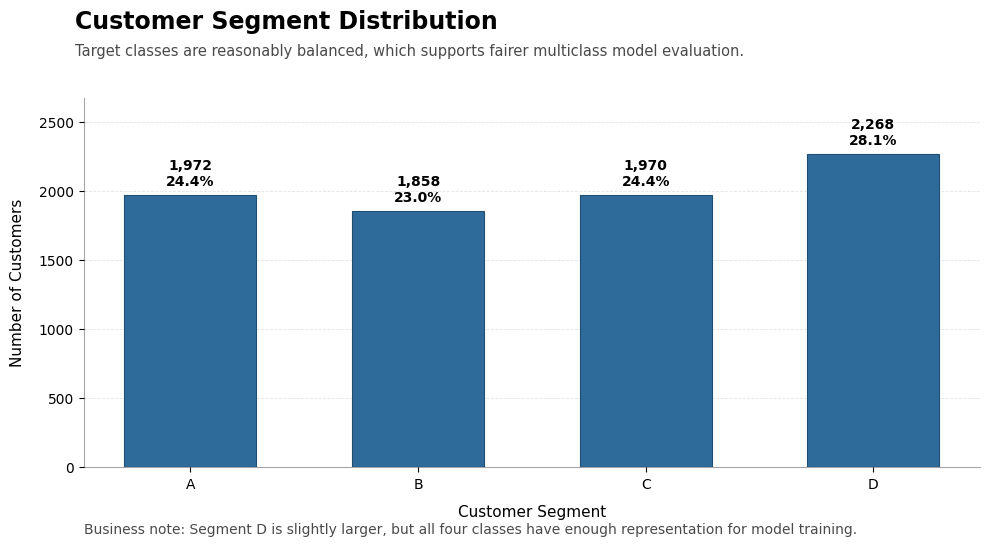

In [7]:
# ============================================================
# Code Cell 3E: BI-Ready Target Distribution Chart
# ============================================================
# Purpose:
# - Visualize the distribution of customer segments
# - Show both customer count and percentage share
# - Create a clean BI-style chart for notebook presentation
#
# Input:
# - target_distribution: table created earlier with segment counts
#
# Output:
# - Professional bar chart showing segment balance
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Prepare chart data
# -----------------------------
# Create a copy so the original target_distribution remains unchanged.
segment_chart_df = target_distribution.copy()

# Sort by segment name to keep A, B, C, D in order.
segment_chart_df = segment_chart_df.sort_values("segment")

# Extract values for easier plotting.
segments = segment_chart_df["segment"]
customer_counts = segment_chart_df["customer_count"]
percentages = segment_chart_df["percentage"]

# -----------------------------
# 2. Create chart canvas
# -----------------------------
# Wider figure gives enough space for title, subtitle, labels, and bars.
fig, ax = plt.subplots(figsize=(10, 6))

# Light background improves readability inside notebooks.
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# -----------------------------
# 3. Plot bars
# -----------------------------
bars = ax.bar(
    segments,
    customer_counts,
    width=0.58,
    color="#2F6B9A",
    edgecolor="#1F4E73",
    linewidth=0.8
)

# -----------------------------
# 4. Add data labels
# -----------------------------
# Each bar shows customer count and percentage share.
for bar, count, pct in zip(bars, customer_counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 45,
        f"{count:,.0f}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="semibold"
    )

# -----------------------------
# 5. Add title and subtitle
# -----------------------------
# fig.text gives better title/subtitle spacing than ax.set_title alone.
fig.text(
    0.08,
    0.95,
    "Customer Segment Distribution",
    fontsize=17,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.08,
    0.905,
    "Target classes are reasonably balanced, which supports fairer multiclass model evaluation.",
    fontsize=10.5,
    ha="left",
    color="#4A4A4A"
)

# -----------------------------
# 6. Format axes
# -----------------------------
ax.set_xlabel("Customer Segment", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Customers", fontsize=11, labelpad=10)

# Add extra space above bars so labels do not touch the top.
ax.set_ylim(0, customer_counts.max() * 1.18)

# Use light horizontal gridlines for easier value comparison.
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Remove unnecessary chart borders for a cleaner BI look.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

# Keep tick labels readable.
ax.tick_params(axis="both", labelsize=10)

# -----------------------------
# 7. Add business note
# -----------------------------
ax.text(
    0.0,
    -0.18,
    "Business note: Segment D is slightly larger, but all four classes have enough representation for model training.",
    transform=ax.transAxes,
    fontsize=10,
    color="#4A4A4A",
    ha="left"
)

# -----------------------------
# 8. Final layout
# -----------------------------
# rect reserves top space for title/subtitle.
plt.tight_layout(rect=[0, 0.05, 1, 0.86])
plt.show()

## 4. Feature and Target Preparation

### Objective

In this section, we separate the dataset into the input features and the target label required for supervised classification.

A Decision Tree learns by comparing customer attributes with the correct customer segment. Therefore, we need to clearly define:

| Object | Meaning | Role in Modelling |
|---|---|---|
| `X` | Customer input features | Used by the model to learn patterns |
| `y` | Customer segment label | Correct answer the model learns to predict |

### Business Context

For this customer segmentation project:

- `X` contains customer attributes such as age, profession, spending score, work experience, and family size.
- `y` contains the segment label from the `Segmentation` column.

The model will learn rules such as:

> Customers with certain demographic and spending patterns are more likely to belong to a specific segment.

### Modelling Note

The `ID` column is removed because it is only a unique identifier. It does not describe customer behavior and should not influence the prediction.

This step connects directly to supervised learning theory:

> The model learns from input features (`X`) and known labels (`y`) so it can later predict labels for unseen customers.

In [8]:
# ============================================================
# Code Cell 4A: Create Feature Matrix X and Target Vector y
# ============================================================
# Purpose:
# - Create X: input features used for prediction
# - Create y: target labels the model should predict
# - Remove ID because it is only an identifier
#
# Key idea:
# - X answers: "What information do we know about the customer?"
# - y answers: "Which customer segment is the correct answer?"
# ============================================================

# -----------------------------
# 1. Define important columns
# -----------------------------

id_column = "ID"                       # Unique customer identifier, not useful for prediction
target_column = "Segmentation"         # Target class the model will predict

# -----------------------------
# 2. Create X: input features
# -----------------------------
# Drop ID because it is not a behavioral/customer feature.
# Drop Segmentation because it is the answer we want to predict.

X = train_df.drop(columns=[id_column, target_column])

# -----------------------------
# 3. Create y: target labels
# -----------------------------
# y contains only the correct customer segment for each row.

y = train_df[target_column]

# -----------------------------
# 4. Check output shapes
# -----------------------------
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

# -----------------------------
# 5. Preview X and y
# -----------------------------
display(X.head())
display(y.head())

Feature matrix X shape: (8068, 9)
Target vector y shape: (8068,)


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


0    D
1    A
2    B
3    B
4    A
Name: Segmentation, dtype: str

### 4.2 Train/Test Split

Before training the Decision Tree, we split the labelled dataset into two parts:

| Dataset Part | Purpose |
|---|---|
| Training data | Used to teach the model |
| Test data | Used to check how well the model works on unseen data |

This is important because we do not want to evaluate the model on the same data it used for learning. If we do that, the model may look better than it really is.

After the split, we will have four objects:

| Object | Meaning |
|---|---|
| `X_train` | Customer features used for training |
| `X_test` | Customer features used for testing |
| `y_train` | Correct segment labels for training |
| `y_test` | Correct segment labels for testing |

### Simple Explanation

The model learns from:

> `X_train` + `y_train`

Then it predicts on:

> `X_test`

Finally, we compare predictions with:

> `y_test`

This tells us whether the model learned useful patterns or only memorized the training data.

In [9]:
# ============================================================
# Code Cell 4B: Split Data into Training and Test Sets
# ============================================================
# Purpose:
# - Split X and y into training and test sets
# - Keep class proportions similar using stratify=y
# - Create clear variables for modelling and evaluation
#
# Theory connection:
# - Training data teaches the model.
# - Test data checks whether the model generalizes to unseen customers.
#
# Output:
# - X_train: customer features for training
# - X_test: customer features for testing
# - y_train: correct labels for training
# - y_test: correct labels for testing
# ============================================================

from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Split features and target
# -----------------------------
# test_size=0.20 means:
# - 80% of rows are used for training
# - 20% of rows are used for testing
#
# stratify=y means:
# - keep the A/B/C/D segment proportions similar in train and test sets
#
# random_state=42 means:
# - make the split reproducible, so results stay the same each time

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# 2. Check split sizes
# -----------------------------
print("Training feature data X_train:", X_train.shape)
print("Test feature data X_test:", X_test.shape)

print("\nTraining target labels y_train:", y_train.shape)
print("Test target labels y_test:", y_test.shape)

# -----------------------------
# 3. Check class balance after split
# -----------------------------
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

Training feature data X_train: (6454, 9)
Test feature data X_test: (1614, 9)

Training target labels y_train: (6454,)
Test target labels y_test: (1614,)

Training target distribution:


Segmentation
A    24.45
B    23.02
C    24.42
D    28.11
Name: proportion, dtype: float64


Test target distribution:


Segmentation
A    24.41
B    23.05
C    24.41
D    28.13
Name: proportion, dtype: float64

### 5.2 Preprocessing Pipeline

Before training the Decision Tree, the feature columns must be converted into a model-ready format.

The dataset contains two feature types:

| Feature Type | Example Columns | Preprocessing Step |
|---|---|---|
| Numerical | `Age`, `Work_Experience`, `Family_Size` | Fill missing values using the median |
| Categorical | `Gender`, `Profession`, `Spending_Score` | Fill missing values and apply one-hot encoding |

This step is important because sklearn Decision Trees cannot directly work with missing values or raw text categories.

The preprocessing pipeline will be fitted only on `X_train`. The same fitted transformation will then be applied to both `X_train` and `X_test`.

This protects the test set from data leakage and keeps the evaluation realistic.

In [10]:
# Code Cell 5B: Build Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Numerical pipeline:

# Missing numerical values are filled with the median.
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical pipeline:

# Missing categorical values are filled with the most frequent category.
# OneHotEncoder converts text categories into numeric dummy columns.
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ColumnTransformer applies the correct preprocessing to each column group.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Preprocessing pipeline created successfully.
Numerical features: 3
Categorical features: 6


### Preprocessing Pipeline Conclusion

The preprocessing pipeline has been created successfully.

It contains two separate preprocessing paths:

| Feature Type | Number of Features | Treatment |
|---|---:|---|
| Numerical | 3 | Missing values filled using the median |
| Categorical | 6 | Missing values filled using the most frequent value, then one-hot encoded |

At this stage, the pipeline is only defined. It has not yet learned values from the training data and has not transformed the feature tables.

The next step is to fit the preprocessing pipeline on `X_train` and then apply the same transformation to both `X_train` and `X_test`.

### 5.3 Apply Preprocessing to Train and Test Data

Now we apply the preprocessing pipeline to the feature data.

The key rule is:

> Fit on the training data, transform both training and test data.

This means:

| Step | Dataset | Purpose |
|---|---|---|
| `fit_transform()` | `X_train` | Learn missing-value replacements and category encoding from training data |
| `transform()` | `X_test` | Apply the same learned preprocessing to unseen test data |

This protects the test data from influencing the training process.

In simple terms:

- `X_train_processed` becomes the model-ready version of the training features.
- `X_test_processed` becomes the model-ready version of the test features.

In [11]:
# Fit and Apply Preprocessing

# Fit only on training data so the preprocessing learns from training rows only.

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same learned preprocessing rules.
# We do NOT fit on X_test because that would cause data leakage.

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing applied successfully.")
print("-" * 40)

# Processed shapes show how one-hot encoding expanded the feature space.
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")

Preprocessing applied successfully.
----------------------------------------
X_train_processed shape: (6454, 28)
X_test_processed shape:  (1614, 28)


### Preprocessing Application Conclusion

The preprocessing pipeline was successfully applied to both the training and test feature sets.

| Object | Shape | Meaning |
|---|---:|---|
| `X_train_processed` | 6,454 × 28 | Model-ready training features |
| `X_test_processed` | 1,614 × 28 | Model-ready test features |

The number of columns increased from 9 to 28 because categorical variables were converted into multiple one-hot encoded columns.

For example, a column such as `Profession` contains several categories. One-hot encoding converts those categories into separate numeric indicator columns so the Decision Tree can use them during training.

The data is now ready for model training.

### 5.4 Processed Feature Names

After preprocessing, the feature matrix has 28 columns instead of the original 9.

This happens because categorical columns were converted into multiple one-hot encoded columns. For example, one original column such as `Profession` can become several model-ready columns such as `Profession_Engineer`, `Profession_Healthcare`, and `Profession_Lawyer`.

The model can train on `X_train_processed`, but for interpretation we also need readable feature names.

These names will be used later for:

| Output | Why Feature Names Matter |
|---|---|
| Decision Tree plot | Shows readable split rules |
| Root feature explanation | Helps explain the first split in business terms |
| Feature importance | Shows which customer attributes matter most |
| SHAP plots | Explains global and local model decisions |

In short:

> `X_train_processed` contains the processed values.  
> `processed_feature_names` contains the matching column names for those processed values.

In [12]:
# Code Cell 5D: Extract Processed Feature Names

# Variable flow: numeric_features -> processed_numeric_features
# Numeric columns keep their original names after imputation.

processed_numeric_features = numeric_features

# Variable flow: categorical_features -> OneHotEncoder -> encoded_categorical_features
# OneHotEncoder creates one new column name for every category it learned from X_train.

encoded_categorical_features = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

# Variable flow:

# processed_numeric_features + encoded_categorical_features -> processed_feature_names
# This final list must match the 28 columns in X_train_processed and X_test_processed.

processed_feature_names = processed_numeric_features + encoded_categorical_features

print("Processed feature names created successfully.")
print("-" * 50)
print(f"Number of processed columns: {len(processed_feature_names)}")

print("\nFirst 15 processed feature names:")
for feature_name in processed_feature_names[:15]:
    print(f"- {feature_name}")

Processed feature names created successfully.
--------------------------------------------------
Number of processed columns: 28

First 15 processed feature names:
- Age
- Work_Experience
- Family_Size
- Gender_Female
- Gender_Male
- Ever_Married_No
- Ever_Married_Yes
- Graduated_No
- Graduated_Yes
- Profession_Artist
- Profession_Doctor
- Profession_Engineer
- Profession_Entertainment
- Profession_Executive
- Profession_Healthcare


## 6. Beginner Task: First Decision Tree Model

### Objective

In this section, we train our first Decision Tree classifier using the preprocessed customer segmentation data.

The official Learning Day 7 beginner task requires:

`DecisionTreeClassifier(max_depth=3)`

We use `max_depth=3` to keep the tree small, readable, and easier to explain.

### Theory Connection

A Decision Tree predicts a class by asking feature-based yes/no questions. Each split tries to reduce impurity and create cleaner customer segment groups.

Limiting the tree depth helps prevent the model from growing too large and memorizing the training data.

### Business Context

For this project, the model learns customer segmentation rules from historical customer data.

The model may learn rules such as:

> Customers with certain demographic, profession, spending, and family characteristics are more likely to belong to a specific customer segment.

### Variable Flow

| Variable | Meaning |
|---|---|
| `X_train_processed` | Model-ready training features |
| `y_train` | Correct segment labels for training |
| `X_test_processed` | Model-ready test features |
| `y_test` | Correct segment labels for evaluation |
| `dt_baseline` | First Decision Tree model |

In [13]:
# Train Baseline Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Variable flow: X_train_processed + y_train -> dt_baseline
# The tree learns customer segment rules from processed training features.

dt_baseline = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Fit means train the model using features and their correct segment labels.

dt_baseline.fit(X_train_processed, y_train)

print("Baseline Decision Tree trained successfully.")
print("-" * 45)
print("Model: DecisionTreeClassifier")
print("Max depth:", dt_baseline.get_depth())
print("Number of leaf nodes:", dt_baseline.get_n_leaves())

Baseline Decision Tree trained successfully.
---------------------------------------------
Model: DecisionTreeClassifier
Max depth: 3
Number of leaf nodes: 8


### 6.2 Decision Tree Visualization

Now we visualize the trained Decision Tree.

This is one of the main advantages of Decision Trees: they are easy to interpret.  
Each internal node shows a split rule, and each leaf node shows the final predicted class.

### What we want to learn from the plot

From this visualization, we can understand:

- which feature appears at the **root node**,
- how the tree splits customers step by step,
- how many levels the tree has,
- which segment is predicted at each leaf.

### Business Value

A visual tree helps translate the model into simple customer segmentation rules.

For example:

> If a customer has certain spending and demographic characteristics, the model may route them toward a specific segment.

This makes the model easier to explain to business stakeholders than many other classification algorithms.

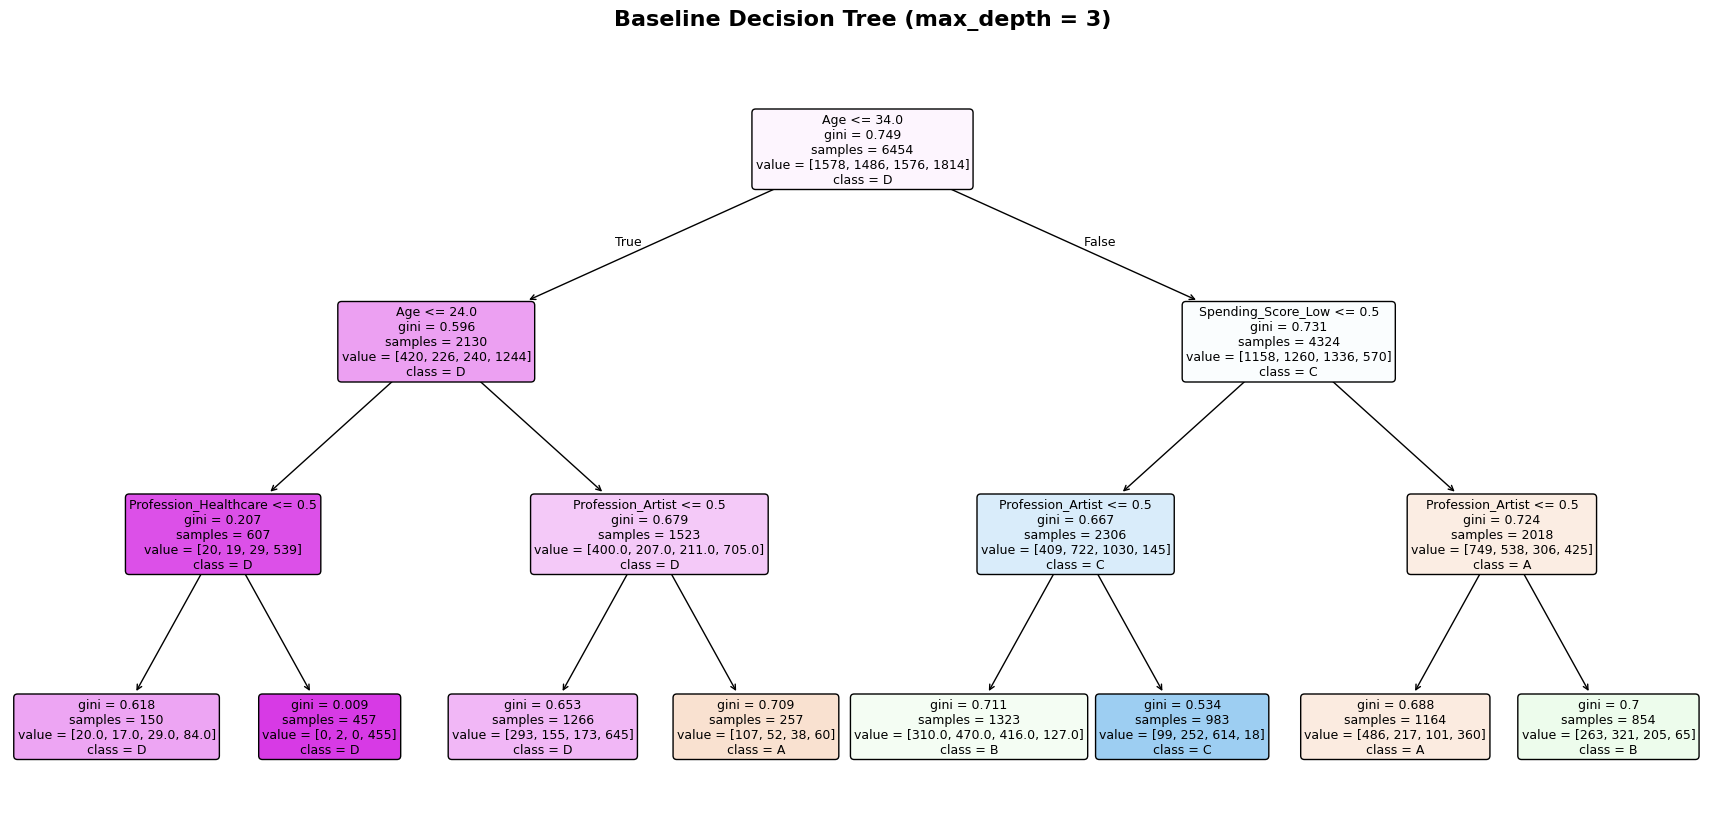

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Variable flow:
# dt_baseline              -> trained Decision Tree model
# processed_feature_names  -> readable names for the 28 processed input columns
# y_train                  -> used here only to get class names for display

class_names = sorted(y_train.unique())  # Segment labels such as A, B, C, D

plt.figure(figsize=(22, 10))

plot_tree(
    dt_baseline,
    feature_names=processed_feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Baseline Decision Tree (max_depth = 3)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.show()

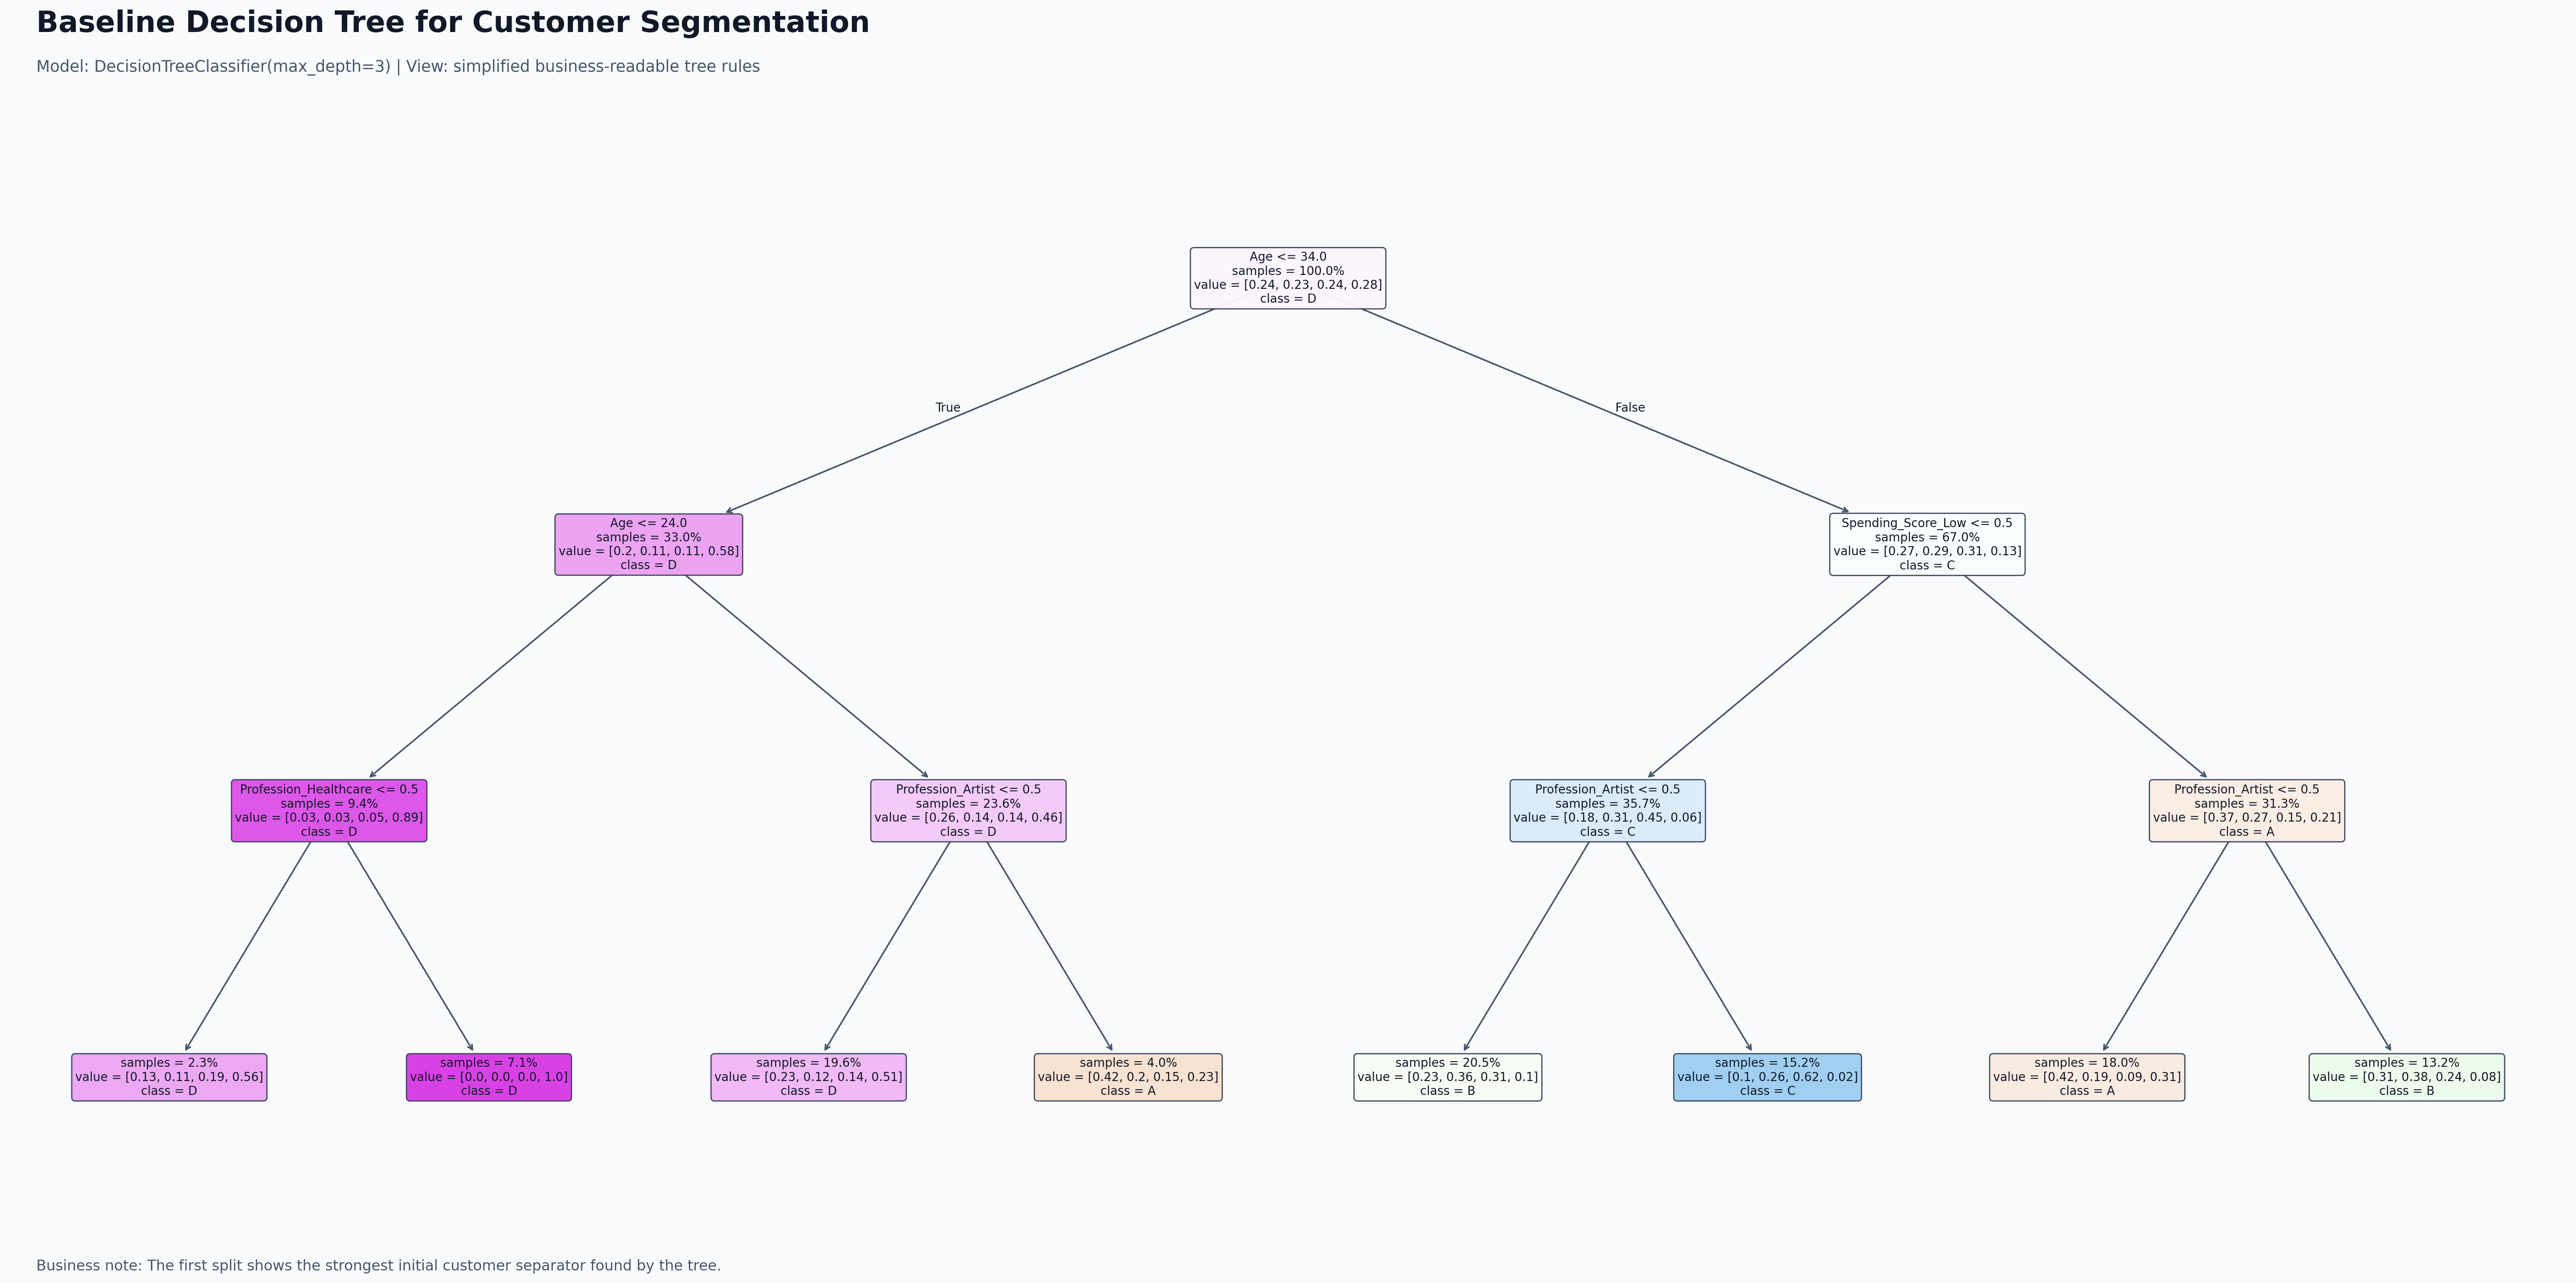

Saved BI-ready tree plot to: outputs/figures/baseline_decision_tree_bi_ready.png


In [15]:
# Code Cell 6B: BI-Ready Decision Tree Visualization

from pathlib import Path
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Variable flow: y_train -> class_names
# These labels appear inside the tree leaves as customer segment classes.
class_names = sorted(y_train.unique())

# Create a large high-resolution canvas for readability.
fig, ax = plt.subplots(figsize=(28, 14), dpi=220)

# Use a clean light BI-style background.
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Variable flow:
# dt_baseline + processed_feature_names + class_names -> readable tree chart
plot_tree(
    dt_baseline,
    feature_names=processed_feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=False,      # hides gini to reduce clutter
    proportion=True,     # shows sample share instead of large raw counts
    precision=2,
    fontsize=9,
    ax=ax
)

# Style node text and node borders for cleaner presentation.
for node_text in ax.texts:
    node_text.set_color("#111827")
    node_text.set_fontfamily("DejaVu Sans")
    node_text.set_fontsize(9)

    node_box = node_text.get_bbox_patch()
    if node_box is not None:
        node_box.set_edgecolor("#334155")
        node_box.set_linewidth(0.9)
        node_box.set_alpha(0.96)

# Style connector arrows so branches are clearly visible.
for node_text in ax.texts:
    if hasattr(node_text, "arrow_patch") and node_text.arrow_patch is not None:
        node_text.arrow_patch.set_color("#475569")
        node_text.arrow_patch.set_linewidth(1.2)

# Add professional title and subtitle with proper spacing.
fig.text(
    0.03,
    0.965,
    "Baseline Decision Tree for Customer Segmentation",
    fontsize=22,
    fontweight="bold",
    color="#111827",
    ha="left"
)

fig.text(
    0.03,
    0.935,
    "Model: DecisionTreeClassifier(max_depth=3) | View: simplified business-readable tree rules",
    fontsize=12,
    color="#475569",
    ha="left"
)

# Add business note at the bottom.
fig.text(
    0.03,
    0.035,
    "Business note: The first split shows the strongest initial customer separator found by the tree.",
    fontsize=11,
    color="#475569",
    ha="left"
)

# Remove axes because this is a tree diagram, not a numeric axis chart.
ax.axis("off")

# Keep enough space for title and business note.
plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.08)

# Save high-resolution image for documentation later.
figure_dir = Path("outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

tree_plot_path = figure_dir / "baseline_decision_tree_bi_ready.png"
fig.savefig(tree_plot_path, bbox_inches="tight", facecolor=fig.get_facecolor())

plt.show()

print(f"Saved BI-ready tree plot to: {tree_plot_path}")

### Decision Tree Visualization Conclusion

The baseline Decision Tree was successfully visualized with a maximum depth of 3.

The tree shows how the model separates customers into segments through a sequence of feature-based rules. Each internal node represents a split condition, and each leaf node represents the predicted customer segment.

The first split appears to be based on `Age`, meaning the model found age to be the strongest first-level separator among the available customer features.

This is useful from a BI perspective because it suggests that customer life stage may play an important role in distinguishing customer segments.

### 6.3 Root Feature Interpretation

The root node is the first split in a Decision Tree.

This is important because the root feature is the first variable 
the model uses to separate the customer segments. 

In simple terms, it is the model's first and strongest question.

For this project, we extract the root feature directly 
from the trained model instead of reading it manually from the chart.

This helps us answer the Beginner task question:

> Which feature is at the root, and what does it mean in context?

In [16]:
# Extract Root Feature and Threshold

# Variable flow: dt_baseline.tree_ -> root_node_feature_index
# The root node is always node 0 in sklearn's tree structure.

root_node_feature_index = dt_baseline.tree_.feature[0]

# Variable flow: root_node_feature_index -> root_feature_name
# This maps the model's feature index back to the readable processed feature name.

root_feature_name = processed_feature_names[root_node_feature_index]

# Variable flow: dt_baseline.tree_ -> root_threshold
# The threshold is the split value used at the root node.

root_threshold = dt_baseline.tree_.threshold[0]

print("Root Node Information")
print("-" * 35)
print(f"Root feature:   {root_feature_name}")
print(f"Root threshold: {root_threshold:.2f}")

Root Node Information
-----------------------------------
Root feature:   Age
Root threshold: 34.00


### Root Feature Interpretation Conclusion

The root feature of the baseline Decision Tree is `Age`, with a threshold of `34.00`.

This means the first question asked by the model is:

> Is the customer aged 34 or younger?

In Decision Tree theory, the root feature is important because it is the first split selected by the model to reduce class impurity. The model found that `Age` was the strongest first-level separator between customer segments.

### Business Interpretation

From a customer segmentation perspective, this suggests that customer age or life stage plays an important role in separating segment groups.

Customers aged 34 or younger follow one decision path, while customers older than 34 follow another path. This indicates that younger and older customers may show different patterns in spending behavior, profession, family size, or segment membership.

This is useful for BI and marketing analytics because age-based segmentation can support:

- customer profiling,
- campaign targeting,
- offer personalization,
- lifecycle-based marketing strategy.

However, this does not mean age alone fully explains customer segmentation. 
It only means age is the strongest first split in this shallow baseline tree.

### 6.4 Baseline Model Accuracy

After training the baseline Decision Tree, we evaluate how well it performs on both training and test data.

We calculate two accuracy scores:

| Metric | Meaning |
|---|---|
| Training accuracy | How well the model predicts the data it learned from |
| Test accuracy | How well the model predicts unseen data |

This comparison helps us check whether the tree is overfitting.

A large gap between training and test accuracy may mean the model has memorized the training data. A smaller gap usually suggests better generalization.

Because this is a multiclass customer segmentation problem, accuracy gives us a quick first view of performance. Later, we will also use confusion matrix, precision, recall, and F1-score for deeper evaluation.

In [17]:
# Calculate Baseline Train and Test Accuracy

from sklearn.metrics import accuracy_score

# Variable flow: dt_baseline + X_train_processed -> y_train_pred_baseline
# These predictions show how well the model performs on training data.

y_train_pred_baseline = dt_baseline.predict(X_train_processed)

# Variable flow: dt_baseline + X_test_processed -> y_test_pred_baseline
# These predictions show how well the model performs on unseen test data.

y_test_pred_baseline = dt_baseline.predict(X_test_processed)

# Compare training predictions with the correct training labels.
train_accuracy_baseline = accuracy_score(y_train, y_train_pred_baseline)

# Compare test predictions with the correct test labels.
test_accuracy_baseline = accuracy_score(y_test, y_test_pred_baseline)

print("Baseline Decision Tree Accuracy")
print("-" * 40)
print(f"Training accuracy: {train_accuracy_baseline:.4f}")
print(f"Test accuracy:     {test_accuracy_baseline:.4f}")
print(f"Train-test gap:    {train_accuracy_baseline - test_accuracy_baseline:.4f}")

Baseline Decision Tree Accuracy
----------------------------------------
Training accuracy: 0.4930
Test accuracy:     0.5105
Train-test gap:    -0.0175


### Baseline Accuracy Conclusion

The baseline Decision Tree with `max_depth=3` produced the following results:

| Metric | Score |
|---|---:|
| Training accuracy | 0.4930 |
| Test accuracy | 0.5105 |
| Train-test gap | -0.0175 |

The test accuracy is slightly higher than the training accuracy. 
This can happen because the test split may contain some records 
that are easier for this shallow tree to classify.

Most importantly, there is no sign of overfitting here. 
If the tree were overfitting, we would expect 
training accuracy to be much higher than test accuracy.

### Interpretation

The model is intentionally simple because `max_depth=3` restricts the tree to only three decision levels. This keeps the tree interpretable, but it also limits how many patterns the model can learn.

The accuracy around 50% suggests that the shallow baseline tree captures some useful segmentation patterns, but it is not yet strong enough to fully separate the four customer segments.

This is a reasonable beginner baseline. In the next steps, we will compare Gini and Entropy, then later use pruning and model tuning to study the balance between interpretability and performance.

### 6.5 Gini vs Entropy Comparison

The official beginner task asks us to train Decision Trees using both splitting criteria:

| Criterion | Meaning |
|---|---|
| `gini` | Measures how mixed the classes are in a node |
| `entropy` | Measures class disorder using information theory |

Both criteria try to answer the same question:

> Which split makes the customer segment groups cleaner?

In this section, we train two shallow Decision Trees with the same `max_depth=3`:

- one using `criterion="gini"`,
- one using `criterion="entropy"`.

We then compare their training accuracy, test accuracy, depth, and number of leaf nodes.

In [18]:
# Code Cell 6E: Train Gini and Entropy Decision Trees

# Variable flow: X_train_processed + y_train -> dt_gini
# This tree uses Gini impurity to choose split rules.

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
dt_gini.fit(X_train_processed, y_train)

# Variable flow: X_train_processed + y_train -> dt_entropy
# This tree uses Entropy to choose split rules.
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
dt_entropy.fit(X_train_processed, y_train)

print("Gini and Entropy trees trained successfully.")
print("-" * 45)
print(f"Gini tree depth:    {dt_gini.get_depth()} | leaves: {dt_gini.get_n_leaves()}")
print(f"Entropy tree depth: {dt_entropy.get_depth()} | leaves: {dt_entropy.get_n_leaves()}")

Gini and Entropy trees trained successfully.
---------------------------------------------
Gini tree depth:    3 | leaves: 8
Entropy tree depth: 3 | leaves: 8


In [19]:
# Code Cell 6F: Compare Gini vs Entropy Accuracy

# Variable flow: trained trees + processed train/test data -> accuracy comparison table
# Each model predicts on both training and test data.

model_comparison_rows = []

for model_name, model in [
    ("Gini", dt_gini),
    ("Entropy", dt_entropy)
]:
    # Predict on training data to check how well the model learned.
    train_predictions = model.predict(X_train_processed)

    # Predict on test data to check generalization on unseen customers.
    test_predictions = model.predict(X_test_processed)

    # Compare predictions with actual labels.
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    # Store results in a clean comparison format.
    model_comparison_rows.append({
        "model": model_name,
        "criterion": model.criterion,
        "depth": model.get_depth(),
        "leaf_nodes": model.get_n_leaves(),
        "train_accuracy": round(train_accuracy, 4),
        "test_accuracy": round(test_accuracy, 4),
        "train_test_gap": round(train_accuracy - test_accuracy, 4)
    })

gini_entropy_comparison = pd.DataFrame(model_comparison_rows)

display(gini_entropy_comparison)

,model,criterion,depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
0,Gini,gini,3,8,0.4930,0.5105,-0.0175
1,Entropy,entropy,3,8,0.4902,0.4969,-0.0067


### Gini vs Entropy: Conclusion

Both trees were trained with the same setting:

`max_depth = 3`

| Criterion | Depth | Leaves | Train Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| Gini | 3 | 8 | 0.4930 | 0.5105 |
| Entropy | 3 | 8 | 0.4902 | 0.4969 |

#### Key Findings

- Both trees have the same depth and number of leaf nodes.
- Gini gives slightly better test accuracy.
- Entropy performs slightly lower on this split.
- No major overfitting is visible because train and test scores are close.

#### Selected Baseline

We keep the **Gini Decision Tree** as the baseline model.

#### Business Interpretation

The Gini tree is slightly better at predicting unseen customer segments.

This does not mean Gini is always better.  
It only means Gini worked better for this dataset and this tree depth.

### 6.6 Gini vs Entropy Accuracy Chart

We now visualize the accuracy comparison between the Gini and Entropy trees.

#### What this chart shows

- Training accuracy
- Test accuracy
- Difference between both criteria

#### Why it matters

A good baseline should have:

- reasonable test accuracy,
- small train-test gap,
- simple and interpretable structure.

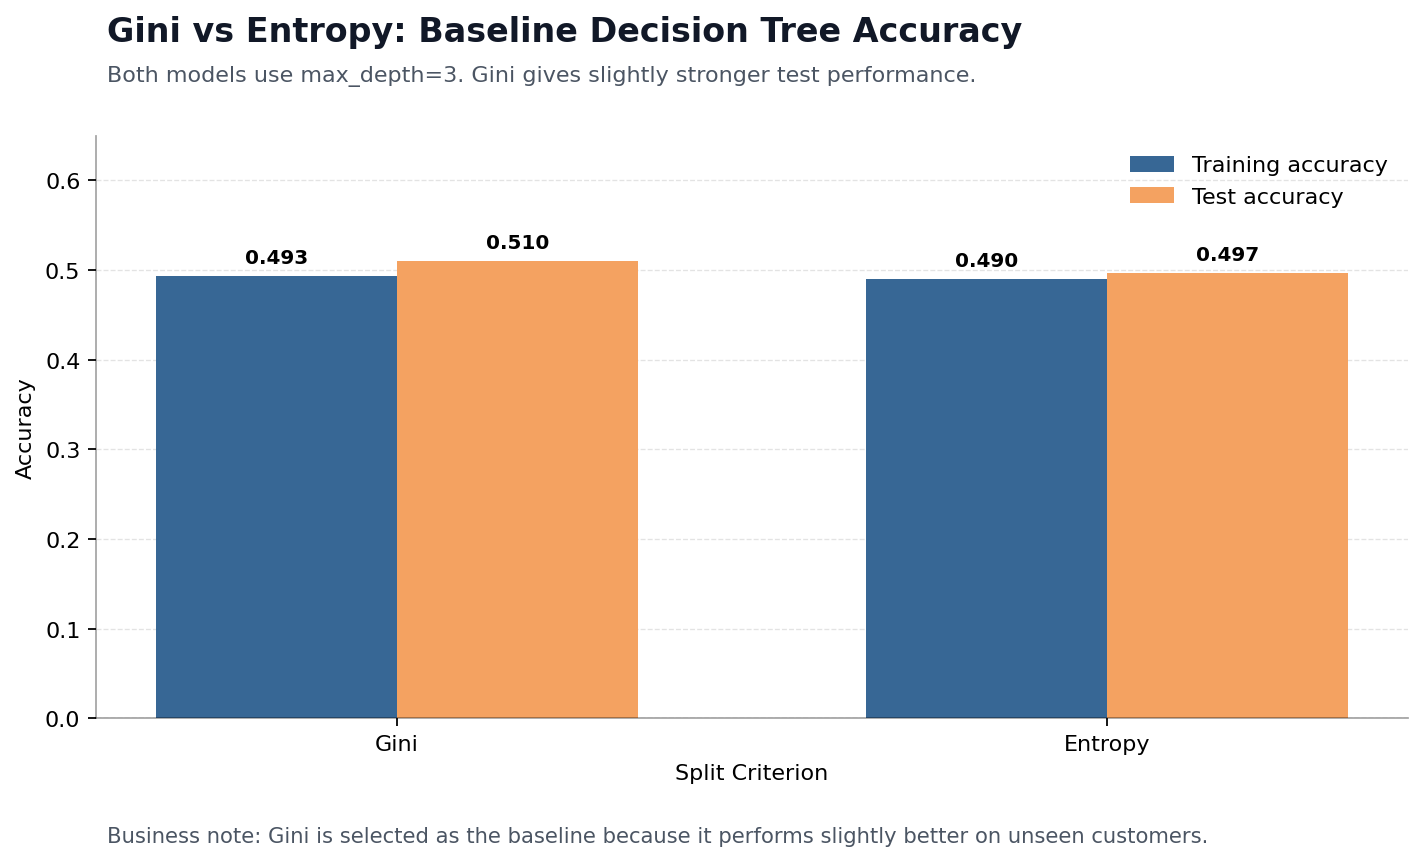

In [20]:
# Code Cell 6G: BI-Ready Gini vs Entropy Accuracy Chart

import matplotlib.pyplot as plt
import numpy as np

# gini_entropy_comparison -> chart data
models = gini_entropy_comparison["model"]
train_scores = gini_entropy_comparison["train_accuracy"]
test_scores = gini_entropy_comparison["test_accuracy"]

# x_positions controls where each model group appears on the x-axis.
x_positions = np.arange(len(models))
bar_width = 0.34

# Create chart canvas.
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=160)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Training accuracy bars.
train_bars = ax.bar(
    x_positions - bar_width / 2,
    train_scores,
    width=bar_width,
    label="Training accuracy",
    color="#376795"
)

# Test accuracy bars.
test_bars = ax.bar(
    x_positions + bar_width / 2,
    test_scores,
    width=bar_width,
    label="Test accuracy",
    color="#F4A261"
)

# Add value labels above bars.
for bars in [train_bars, test_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="semibold"
        )

# Title and subtitle.
fig.text(
    0.08,
    0.94,
    "Gini vs Entropy: Baseline Decision Tree Accuracy",
    fontsize=15,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.895,
    "Both models use max_depth=3. Gini gives slightly stronger test performance.",
    fontsize=10,
    ha="left",
    color="#4B5563"
)

# Format axes.
ax.set_xticks(x_positions)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.65)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Split Criterion")

# Light grid improves readability.
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Remove visual clutter.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.legend(frameon=False, loc="upper right")

# Short business note.
fig.text(
    0.08,
    0.03,
    "Business note: Gini is selected as the baseline because it performs slightly better on unseen customers.",
    fontsize=9.5,
    color="#4B5563",
    ha="left"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.86])
plt.show()

### Gini vs Entropy Chart Conclusion

The chart confirms that both Gini and Entropy perform similarly with `max_depth=3`.

#### Key Findings

- Gini has slightly higher test accuracy.
- Both models show a small train-test gap.
- There is no strong sign of overfitting at this depth.

#### Selected Model

We continue with the **Gini Decision Tree** as the baseline model.

This model is simple, interpretable, and performs slightly better on unseen customer data.

## 7. Baseline Model Evaluation

### Objective

Accuracy gives us a quick performance score, but it is not enough for multiclass classification.

Our target has four customer segments:

| Segment | Meaning |
|---|---|
| A | Customer segment A |
| B | Customer segment B |
| C | Customer segment C |
| D | Customer segment D |

### Why We Need Deeper Evaluation

A model can have acceptable overall accuracy but still perform badly for one segment.

So we will evaluate the Gini baseline using:

| Evaluation Tool | Purpose |
|---|---|
| Accuracy | Overall correctness |
| Classification report | Precision, recall, and F1-score by segment |
| Confusion matrix | Shows which segments are confused with each other |

### Variable Flow

| Variable | Meaning |
|---|---|
| `dt_gini` | Selected baseline Decision Tree |
| `X_test_processed` | Processed test features |
| `y_test` | True segment labels |
| `y_test_pred_gini` | Predicted segment labels |

In [21]:
# Create Predictions for Gini Baseline

# Variable flow: dt_gini + X_train_processed -> y_train_pred_gini
# These predictions help check model fit on training data.
y_train_pred_gini = dt_gini.predict(X_train_processed)

# Variable flow: dt_gini + X_test_processed -> y_test_pred_gini
# These predictions are used for real evaluation on unseen customers.
y_test_pred_gini = dt_gini.predict(X_test_processed)

print("Gini baseline predictions created successfully.")
print("-" * 50)
print(f"Training predictions: {len(y_train_pred_gini):,}")
print(f"Test predictions:     {len(y_test_pred_gini):,}")

Gini baseline predictions created successfully.
--------------------------------------------------
Training predictions: 6,454
Test predictions:     1,614


### 7.2 Classification Report

The classification report shows model performance for each customer segment.

#### Metrics Used

| Metric | Meaning |
|---|---|
| Precision | When the model predicts a segment, how often it is correct |
| Recall | Out of all real customers in a segment, how many the model finds |
| F1-score | Balance between precision and recall |
| Support | Number of real customers in each segment |

#### Why This Matters

Accuracy gives only one overall score.

The classification report shows whether the model performs equally well across all customer segments or struggles with specific segments.

In [22]:
# Code Cell 7B: Classification Report for Gini Baseline

from sklearn.metrics import classification_report

# Variable flow: y_test + y_test_pred_gini -> classification_report_dict
# This compares true segment labels with predicted segment labels.
classification_report_dict = classification_report(
    y_test,
    y_test_pred_gini,
    output_dict=True
)

# Variable flow: classification_report_dict -> classification_report_df
# Convert report into a dataframe for cleaner notebook display.
classification_report_df = (
    pd.DataFrame(classification_report_dict)
    .transpose()
    .round(3)
)

display(classification_report_df)

,precision,recall,f1-score,support
A,0.416,0.363,0.388,394.000
B,0.381,0.540,0.447,372.000
C,0.653,0.411,0.505,394.000
D,0.644,0.700,0.671,454.000
accuracy,0.511,0.511,0.511,0.511
macro avg,0.523,0.504,0.502,1614.000
weighted avg,0.530,0.511,0.509,1614.000


### Classification Report Conclusion

The Gini baseline Decision Tree achieved an overall test accuracy of **0.511**.

#### Key Findings

| Segment | Main Observation |
|---|---|
| A | Weak performance. Recall is low, so many actual Segment A customers are missed. |
| B | Recall is stronger, but precision is low. The model predicts B often, but many predictions are wrong. |
| C | Best precision, but recall is low. When the model predicts C, it is often correct, but it misses many actual C customers. |
| D | Best overall segment performance with the highest F1-score. |

#### Business Interpretation

The model performs best for **Segment D** and struggles more with **Segments A and B**.

This means the shallow tree can identify some customer groups, but the segmentation boundaries are still overlapping. A depth-3 tree is easy to explain, but it is too simple to fully capture all customer segment patterns.

#### Next Step

We will use a confusion matrix to see exactly which customer segments are being confused with each other.

### 7.3 Confusion Matrix with TP / FP / FN / TN Logic

The confusion matrix shows how the model predicts each customer segment.

#### How to Read This Chart

| Area | Meaning |
|---|---|
| Diagonal cells | True Positives for that segment |
| Off-diagonal cells | Misclassifications |
| Row direction | Actual segment |
| Column direction | Predicted segment |

#### Multiclass TP / FP / FN / TN Logic

For multiclass classification, TP / FP / FN / TN are interpreted one segment at a time.

Example for Segment A:

| Term | Meaning |
|---|---|
| TP | Actual A predicted as A |
| FP | Other segments predicted as A |
| FN | Actual A predicted as another segment |
| TN | Other segments not predicted as A |

This helps us understand not only where the model is correct, but also which customer segments are being confused.

In [23]:
# Code Cell 7C1: Confusion Matrix and One-vs-Rest Summary

from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

# y_test + y_test_pred_gini -> confusion_values
segment_labels = sorted(y_test.unique())

confusion_values = confusion_matrix(
    y_test,
    y_test_pred_gini,
    labels=segment_labels
)

# confusion_values -> readable matrix table
confusion_matrix_df = pd.DataFrame(
    confusion_values,
    index=[f"Actual {label}" for label in segment_labels],
    columns=[f"Predicted {label}" for label in segment_labels]
)

# confusion_values -> one-vs-rest TP/FP/FN/TN summary
tp_fp_fn_tn_rows = []

total_predictions = confusion_values.sum()

for index, segment in enumerate(segment_labels):
    tp = confusion_values[index, index]                         # Actual segment predicted correctly
    fn = confusion_values[index, :].sum() - tp                  # Actual segment predicted as other classes
    fp = confusion_values[:, index].sum() - tp                  # Other classes predicted as this segment
    tn = total_predictions - tp - fp - fn                       # Everything else correctly not this segment

    tp_fp_fn_tn_rows.append({
        "segment": segment,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

tp_fp_fn_tn_df = pd.DataFrame(tp_fp_fn_tn_rows)

print("Confusion Matrix")
display(confusion_matrix_df)

print("\nOne-vs-Rest TP / FP / FN / TN Summary")
display(tp_fp_fn_tn_df)

Confusion Matrix


,Predicted A,Predicted B,Predicted C,Predicted D
Actual A,143,142,21,88
Actual B,73,201,62,36
Actual C,40,140,162,52
Actual D,88,45,3,318



One-vs-Rest TP / FP / FN / TN Summary


,segment,TP,FP,FN,TN
0,A,143,201,251,1019
1,B,201,327,171,915
2,C,162,86,232,1134
3,D,318,176,136,984


In [24]:
# Code Cell 7C1: Confusion Matrix and One-vs-Rest Summary

from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

# y_test + y_test_pred_gini -> confusion_values
segment_labels = sorted(y_test.unique())

confusion_values = confusion_matrix(
    y_test,
    y_test_pred_gini,
    labels=segment_labels
)

# confusion_values -> readable matrix table
confusion_matrix_df = pd.DataFrame(
    confusion_values,
    index=[f"Actual {label}" for label in segment_labels],
    columns=[f"Predicted {label}" for label in segment_labels]
)

# confusion_values -> one-vs-rest TP/FP/FN/TN summary
tp_fp_fn_tn_rows = []

total_predictions = confusion_values.sum()

for index, segment in enumerate(segment_labels):
    tp = confusion_values[index, index]                         # Actual segment predicted correctly
    fn = confusion_values[index, :].sum() - tp                  # Actual segment predicted as other classes
    fp = confusion_values[:, index].sum() - tp                  # Other classes predicted as this segment
    tn = total_predictions - tp - fp - fn                       # Everything else correctly not this segment

    tp_fp_fn_tn_rows.append({
        "segment": segment,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

tp_fp_fn_tn_df = pd.DataFrame(tp_fp_fn_tn_rows)

print("Confusion Matrix")
display(confusion_matrix_df)

print("\nOne-vs-Rest TP / FP / FN / TN Summary")
display(tp_fp_fn_tn_df)

Confusion Matrix


,Predicted A,Predicted B,Predicted C,Predicted D
Actual A,143,142,21,88
Actual B,73,201,62,36
Actual C,40,140,162,52
Actual D,88,45,3,318



One-vs-Rest TP / FP / FN / TN Summary


,segment,TP,FP,FN,TN
0,A,143,201,251,1019
1,B,201,327,171,915
2,C,162,86,232,1134
3,D,318,176,136,984


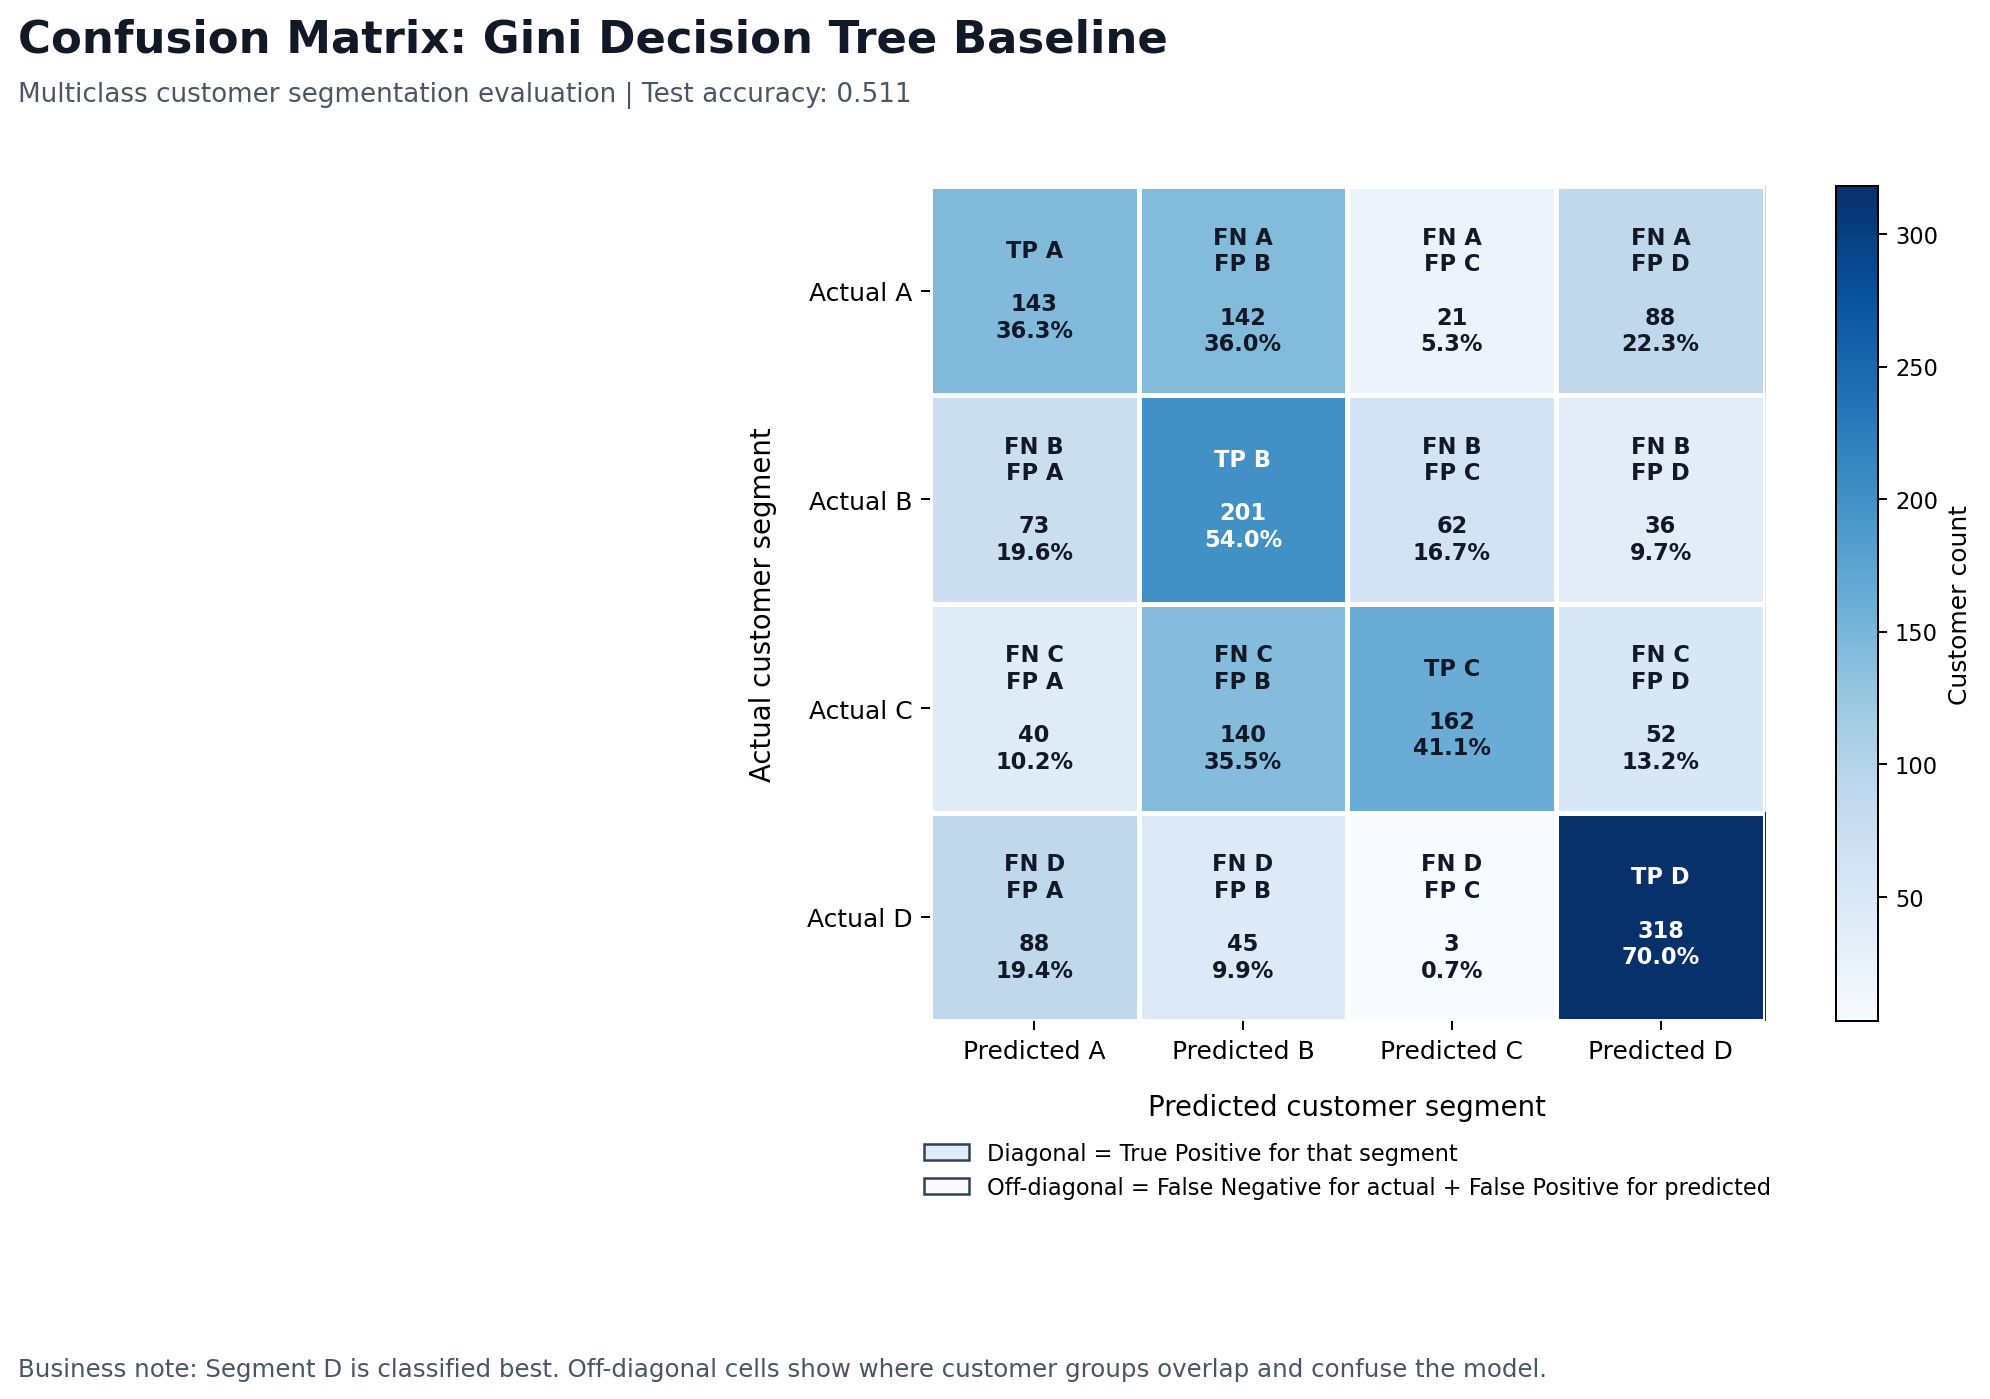

Saved confusion matrix chart to: outputs/figures/gini_baseline_confusion_matrix_tp_fp_fn.png


In [25]:
# Code Cell 7C2: Super BI-Ready Confusion Matrix Heatmap

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# confusion_values -> row percentages
row_totals = confusion_values.sum(axis=1, keepdims=True)
row_percentages = np.divide(confusion_values, row_totals) * 100

# y_test + y_test_pred_gini -> baseline accuracy
baseline_test_accuracy = accuracy_score(y_test, y_test_pred_gini)

fig, ax = plt.subplots(figsize=(12, 8), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Main heatmap
heatmap = ax.imshow(confusion_values, cmap="Blues")

# Colorbar
colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.04, pad=0.035)
colorbar.set_label("Customer count", fontsize=10)
colorbar.ax.tick_params(labelsize=9)

max_value = confusion_values.max()

# Add TP / FP / FN labels inside cells
for row_index in range(confusion_values.shape[0]):
    for col_index in range(confusion_values.shape[1]):
        count = confusion_values[row_index, col_index]
        percentage = row_percentages[row_index, col_index]

        actual_segment = segment_labels[row_index]
        predicted_segment = segment_labels[col_index]

        is_correct_cell = row_index == col_index
        cell_status = f"TP {actual_segment}" if is_correct_cell else f"FN {actual_segment}\nFP {predicted_segment}"

        text_color = "white" if count > max_value * 0.55 else "#111827"

        ax.text(
            col_index,
            row_index,
            f"{cell_status}\n\n{count}\n{percentage:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="semibold",
            color=text_color
        )

# Axis labels
ax.set_xticks(np.arange(len(segment_labels)))
ax.set_yticks(np.arange(len(segment_labels)))

ax.set_xticklabels([f"Predicted {label}" for label in segment_labels], fontsize=10)
ax.set_yticklabels([f"Actual {label}" for label in segment_labels], fontsize=10)

ax.set_xlabel("Predicted customer segment", fontsize=11, labelpad=12)
ax.set_ylabel("Actual customer segment", fontsize=11, labelpad=12)

# Cell borders
ax.set_xticks(np.arange(-0.5, len(segment_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(segment_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Title
fig.text(
    0.07,
    0.955,
    "Confusion Matrix: Gini Decision Tree Baseline",
    fontsize=18,
    fontweight="bold",
    ha="left",
    color="#111827"
)

# Subtitle
fig.text(
    0.07,
    0.92,
    f"Multiclass customer segmentation evaluation | Test accuracy: {baseline_test_accuracy:.3f}",
    fontsize=10.5,
    ha="left",
    color="#4B5563"
)

# Legend explanation
legend_items = [
    Patch(facecolor="#DDEBFA", edgecolor="#334155", label="Diagonal = True Positive for that segment"),
    Patch(facecolor="#F8FAFC", edgecolor="#334155", label="Off-diagonal = False Negative for actual + False Positive for predicted")
]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=9,
    ncol=1
)

# Business note
fig.text(
    0.07,
    0.035,
    "Business note: Segment D is classified best. Off-diagonal cells show where customer groups overlap and confuse the model.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0.11, 1, 0.88])

# Save output
figure_dir = Path("outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

confusion_matrix_path = figure_dir / "gini_baseline_confusion_matrix_tp_fp_fn.png"
fig.savefig(confusion_matrix_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved confusion matrix chart to: {confusion_matrix_path}")

## 8. Intermediate Task: Pruning with `min_samples_leaf`

### Objective

We now test how tree complexity changes when we control the minimum number of samples required in each leaf node.

### Concept

`min_samples_leaf` tells the Decision Tree:

> Do not create a final leaf if it contains too few customers.

This helps reduce overfitting.

| Value | Tree Behavior |
|---:|---|
| 1 | Very flexible, may overfit |
| 5 | Slightly controlled |
| 10 | More stable |
| 20 | Simpler, may start underfitting |

### What We Compare

For each value, we calculate:

- training accuracy,
- test accuracy,
- train-test gap,
- tree depth,
- number of leaf nodes.

### Goal

Find where the model becomes too simple or starts losing useful predictive power.

In [26]:
# Compare min_samples_leaf Values

leaf_values = [1, 5, 10, 20]
leaf_results = []

for leaf_size in leaf_values:
    # X_train_processed + y_train -> tree_leaf_model
    # Each model uses a different minimum leaf size.
    tree_leaf_model = DecisionTreeClassifier(
        criterion="gini",
        min_samples_leaf=leaf_size,
        random_state=42
    )

    # Train current tree on processed training data.
    tree_leaf_model.fit(X_train_processed, y_train)

    # Current model -> train/test predictions
    train_pred = tree_leaf_model.predict(X_train_processed)
    test_pred = tree_leaf_model.predict(X_test_processed)

    # Predictions + true labels -> accuracy scores
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Store one row per model setting.
    leaf_results.append({
        "min_samples_leaf": leaf_size,
        "tree_depth": tree_leaf_model.get_depth(),
        "leaf_nodes": tree_leaf_model.get_n_leaves(),
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "train_test_gap": round(train_acc - test_acc, 4)
    })

# leaf_results -> leaf_results_df
leaf_results_df = pd.DataFrame(leaf_results)

display(leaf_results_df)

,min_samples_leaf,tree_depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
0,1,30,3181,0.9558,0.4226,0.5333
1,5,20,903,0.6763,0.4777,0.1986
2,10,17,456,0.6145,0.4932,0.1213
3,20,15,227,0.5708,0.5149,0.0559


### `min_samples_leaf` Results: Initial Interpretation

The results show how tree complexity changes when `min_samples_leaf` increases.

| `min_samples_leaf` | Tree Depth | Leaf Nodes | Train Accuracy | Test Accuracy | Interpretation |
|---:|---:|---:|---:|---:|---|
| 1 | 30 | 3,181 | 0.9558 | 0.4226 | Strong overfitting |
| 5 | 20 | 903 | 0.6763 | 0.4777 | Still overfitting, but improved |
| 10 | 17 | 456 | 0.6145 | 0.4932 | More controlled |
| 20 | 15 | 227 | 0.5708 | 0.5149 | Best test accuracy in this comparison |

#### Key Findings

- `min_samples_leaf=1` creates a very deep tree with 3,181 leaves.
- Training accuracy is very high, but test accuracy is poor.
- This is a strong sign of overfitting.
- Increasing `min_samples_leaf` reduces tree complexity.
- `min_samples_leaf=20` gives the best test accuracy here.

#### Business Interpretation

A tree with very small leaves creates overly specific customer rules.

For example:

> A tiny group of customers may be classified based on patterns that do not generalize.

A larger `min_samples_leaf` forces the model to create broader, more stable customer segment rules.

### 8.2 Train vs Test Accuracy by `min_samples_leaf`

We now visualize how training and test accuracy change as `min_samples_leaf` increases.

#### What to Look For

- Large train-test gap → overfitting
- Low train and low test accuracy → underfitting
- Higher test accuracy with smaller gap → better generalization

#### Goal

Find the setting that gives the best balance between model performance and tree simplicity.

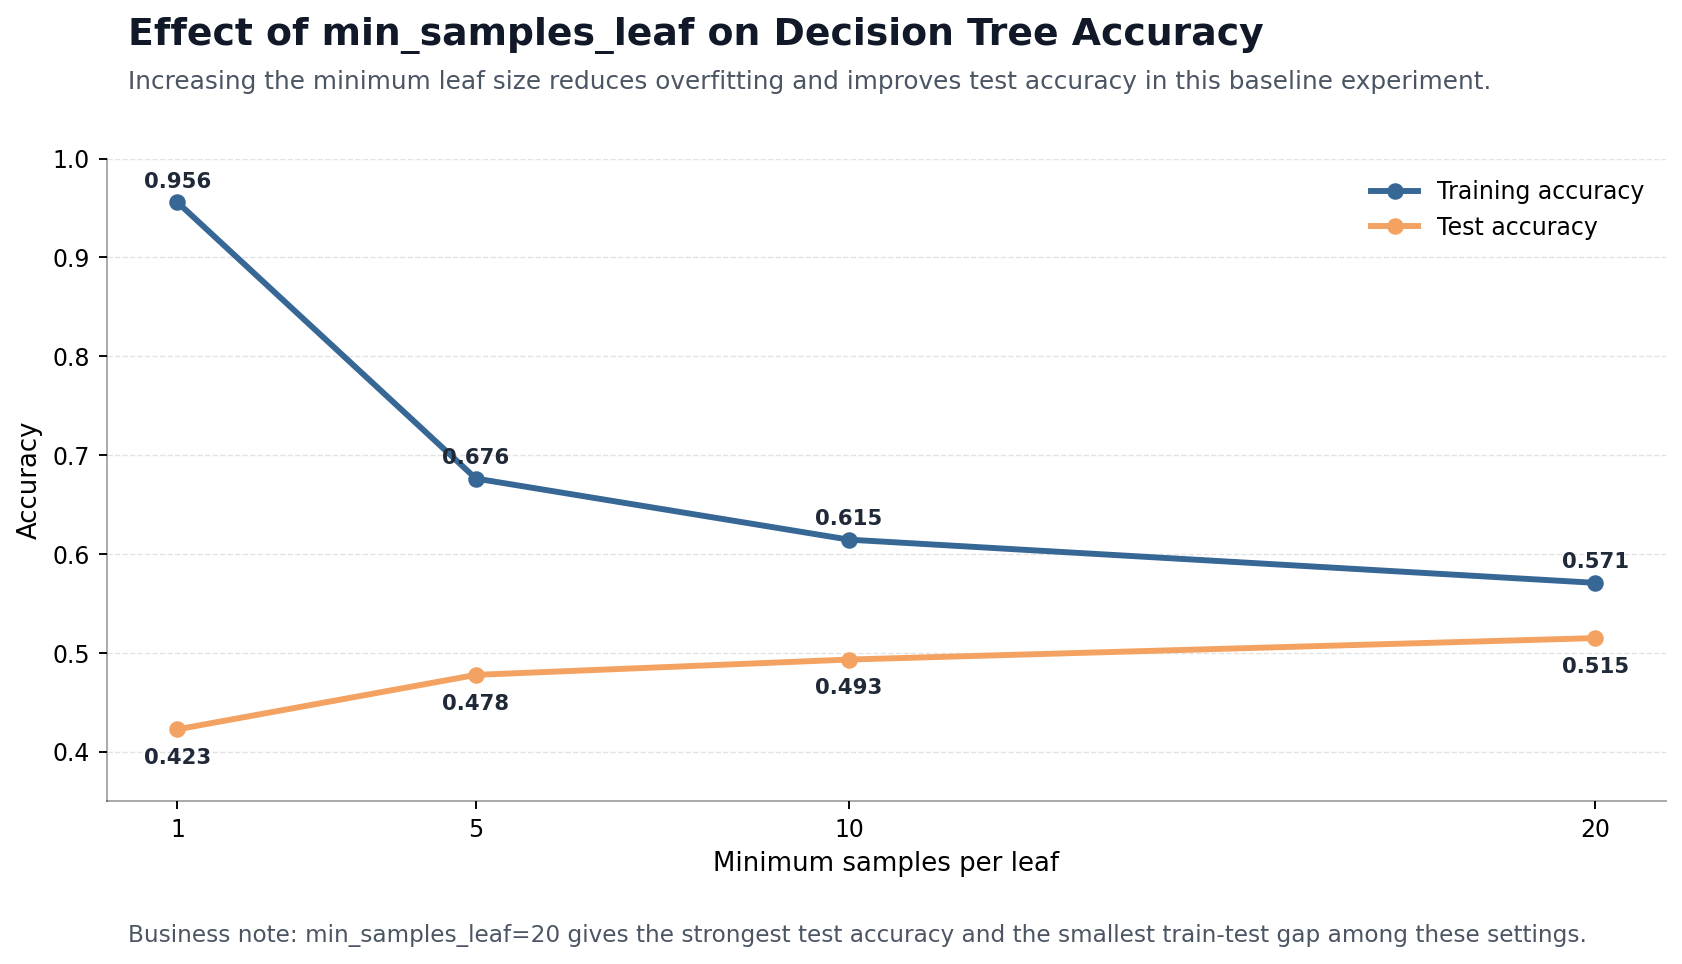

In [27]:
# Code Cell 8B: Train vs Test Accuracy by min_samples_leaf

import matplotlib.pyplot as plt

# leaf_results_df -> chart data
leaf_sizes = leaf_results_df["min_samples_leaf"]
train_accuracy = leaf_results_df["train_accuracy"]
test_accuracy = leaf_results_df["test_accuracy"]

fig, ax = plt.subplots(figsize=(10, 5.8), dpi=170)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Plot training accuracy trend.
ax.plot(
    leaf_sizes,
    train_accuracy,
    marker="o",
    linewidth=2.5,
    label="Training accuracy",
    color="#376795"
)

# Plot test accuracy trend.
ax.plot(
    leaf_sizes,
    test_accuracy,
    marker="o",
    linewidth=2.5,
    label="Test accuracy",
    color="#F4A261"
)

# Add value labels close to each point.
for x_value, y_value in zip(leaf_sizes, train_accuracy):
    ax.text(
        x_value,
        y_value + 0.015,
        f"{y_value:.3f}",
        ha="center",
        fontsize=9,
        fontweight="semibold",
        color="#1F2937"
    )

for x_value, y_value in zip(leaf_sizes, test_accuracy):
    ax.text(
        x_value,
        y_value - 0.035,
        f"{y_value:.3f}",
        ha="center",
        fontsize=9,
        fontweight="semibold",
        color="#1F2937"
    )

# Title and subtitle.
fig.text(
    0.08,
    0.94,
    "Effect of min_samples_leaf on Decision Tree Accuracy",
    fontsize=16,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.895,
    "Increasing the minimum leaf size reduces overfitting and improves test accuracy in this baseline experiment.",
    fontsize=10.5,
    ha="left",
    color="#4B5563"
)

# Axis formatting.
ax.set_xlabel("Minimum samples per leaf", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_xticks(leaf_sizes)
ax.set_ylim(0.35, 1.0)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.legend(frameon=False, loc="upper right")

# Business note.
fig.text(
    0.08,
    0.03,
    "Business note: min_samples_leaf=20 gives the strongest test accuracy and the smallest train-test gap among these settings.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.86])
plt.show()

### `min_samples_leaf` Accuracy Chart Conclusion

The chart shows a clear improvement in generalization as `min_samples_leaf` increases.

#### Key Findings

- `min_samples_leaf=1` strongly overfits.
- Training accuracy is very high, but test accuracy is weak.
- As `min_samples_leaf` increases, the train-test gap becomes smaller.
- `min_samples_leaf=20` gives the best test accuracy in this comparison.

#### Underfitting Check

Underfitting does **not clearly start** within the tested range.

At `min_samples_leaf=20`:

- test accuracy is highest,
- train-test gap is smallest,
- the model is simpler but still useful.

So, based on these four tested values, `min_samples_leaf=20` is the best setting.

#### Business Interpretation

A larger leaf size forces the tree to create broader customer rules.

This helps avoid overly specific rules based on tiny customer groups and creates a more stable segmentation model.

### 8.3 Cost-Complexity Pruning

Cost-complexity pruning is another way to control Decision Tree complexity.

#### Concept

A fully grown tree can become too complex and overfit the training data.

`ccp_alpha` adds a penalty for complexity:

| `ccp_alpha` Value | Effect |
|---:|---|
| Low | Larger tree |
| Medium | More balanced tree |
| High | Smaller tree |

#### Goal

We train multiple trees with different `ccp_alpha` values and compare test accuracy.

This helps us find a simpler tree that still performs well on unseen customers.

In [28]:
# Code Cell 8C: Get Cost-Complexity Pruning Path

# X_train_processed + y_train -> unpruned tree pruning path
# The path gives possible ccp_alpha values for pruning.
pruning_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

pruning_path = pruning_model.cost_complexity_pruning_path(
    X_train_processed,
    y_train
)

# pruning_path -> ccp_alphas
# Each alpha value represents one possible pruning strength.
ccp_alphas = pruning_path.ccp_alphas

print("Cost-complexity pruning path created.")
print("-" * 45)
print(f"Number of alpha values: {len(ccp_alphas):,}")
print(f"Smallest alpha: {ccp_alphas.min():.6f}")
print(f"Largest alpha:  {ccp_alphas.max():.6f}")

Cost-complexity pruning path created.
---------------------------------------------
Number of alpha values: 1,476
Smallest alpha: 0.000000
Largest alpha:  0.062431


### Cost-Complexity Pruning Path Conclusion

The pruning path created **1,476 possible `ccp_alpha` values**.

#### Key Findings

| Item | Value |
|---|---:|
| Number of alpha values | 1,476 |
| Smallest alpha | 0.000000 |
| Largest alpha | 0.062431 |

#### Interpretation

Each `ccp_alpha` value represents a possible pruning strength.

- `ccp_alpha = 0` keeps the tree very large.
- Larger `ccp_alpha` values prune more branches.
- Very large values can make the tree too simple.

To keep the notebook efficient, we will test a smaller representative sample of alpha values instead of training 1,476 separate trees.

In [29]:
# Code Cell 8D: Train Pruned Trees Across Sampled ccp_alpha Values

# ccp_alphas -> sampled_alphas
# We sample alpha values to keep the notebook fast and readable.
sampled_alphas = np.linspace(
    ccp_alphas.min(),
    ccp_alphas.max(),
    25
)

pruning_results = []

for alpha in sampled_alphas:
    # alpha -> pruned_tree_model
    # Higher alpha means stronger pruning.
    pruned_tree_model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42,
        ccp_alpha=alpha
    )

    # X_train_processed + y_train -> trained pruned tree
    pruned_tree_model.fit(X_train_processed, y_train)

    # trained tree -> train/test predictions
    train_pred = pruned_tree_model.predict(X_train_processed)
    test_pred = pruned_tree_model.predict(X_test_processed)

    # predictions + true labels -> accuracy scores
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    pruning_results.append({
        "ccp_alpha": alpha,
        "tree_depth": pruned_tree_model.get_depth(),
        "leaf_nodes": pruned_tree_model.get_n_leaves(),
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "train_test_gap": round(train_acc - test_acc, 4)
    })

# pruning_results -> pruning_results_df
pruning_results_df = pd.DataFrame(pruning_results)

display(pruning_results_df.head(10))
display(pruning_results_df.sort_values("test_accuracy", ascending=False).head(5))

,ccp_alpha,tree_depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
0,0.000000,30,3181,0.9558,0.4226,0.5333
1,0.002601,4,10,0.5062,0.5099,-0.0037
2,0.005203,3,6,0.4857,0.4988,-0.0130
3,0.007804,3,6,0.4857,0.4988,-0.0130
4,0.010405,3,5,0.4768,0.4994,-0.0226
5,0.013006,2,4,0.4684,0.4734,-0.0050
6,0.015608,2,4,0.4684,0.4734,-0.0050
7,0.018209,2,3,0.4684,0.4734,-0.0050
8,0.020810,2,3,0.4684,0.4734,-0.0050
9,0.023412,2,3,0.4684,0.4734,-0.0050


,ccp_alpha,tree_depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
1,0.002601,4,10,0.5062,0.5099,-0.0037
4,0.010405,3,5,0.4768,0.4994,-0.0226
2,0.005203,3,6,0.4857,0.4988,-0.0130
3,0.007804,3,6,0.4857,0.4988,-0.0130
5,0.013006,2,4,0.4684,0.4734,-0.0050


### Cost-Complexity Pruning Results: Initial Interpretation

The pruning experiment shows how `ccp_alpha` controls Decision Tree complexity.

#### Key Findings

| `ccp_alpha` | Depth | Leaves | Test Accuracy | Interpretation |
|---:|---:|---:|---:|---|
| 0.000000 | 30 | 3,181 | 0.4226 | Severe overfitting |
| 0.002601 | 4 | 10 | 0.5099 | Best test accuracy in sampled values |
| 0.005203 | 3 | 6 | 0.4988 | Simpler, slightly lower accuracy |
| 0.010405 | 3 | 5 | 0.4994 | Very compact tree |
| 0.020810 | 2 | 3 | 0.4734 | Too simple |

#### Best Sampled Alpha

The best sampled value is:

`ccp_alpha = 0.002601`

This tree has:

- depth = 4,
- leaf nodes = 10,
- test accuracy = 0.5099,
- very small train-test gap.

#### Interpretation

The unpruned tree strongly overfits.

A small amount of pruning creates a much simpler and more stable tree.  
However, too much pruning removes useful decision rules and reduces performance.

### 8.5 Cost-Complexity Pruning Chart

We now visualize how training and test accuracy change as `ccp_alpha` increases.

#### What to Look For

- `ccp_alpha = 0` usually creates a large, overfit tree.
- Small alpha values can improve generalization.
- Large alpha values can over-prune the tree.

#### Goal

Select a pruned tree that balances:

- test accuracy,
- low train-test gap,
- reasonable tree size,
- interpretability.

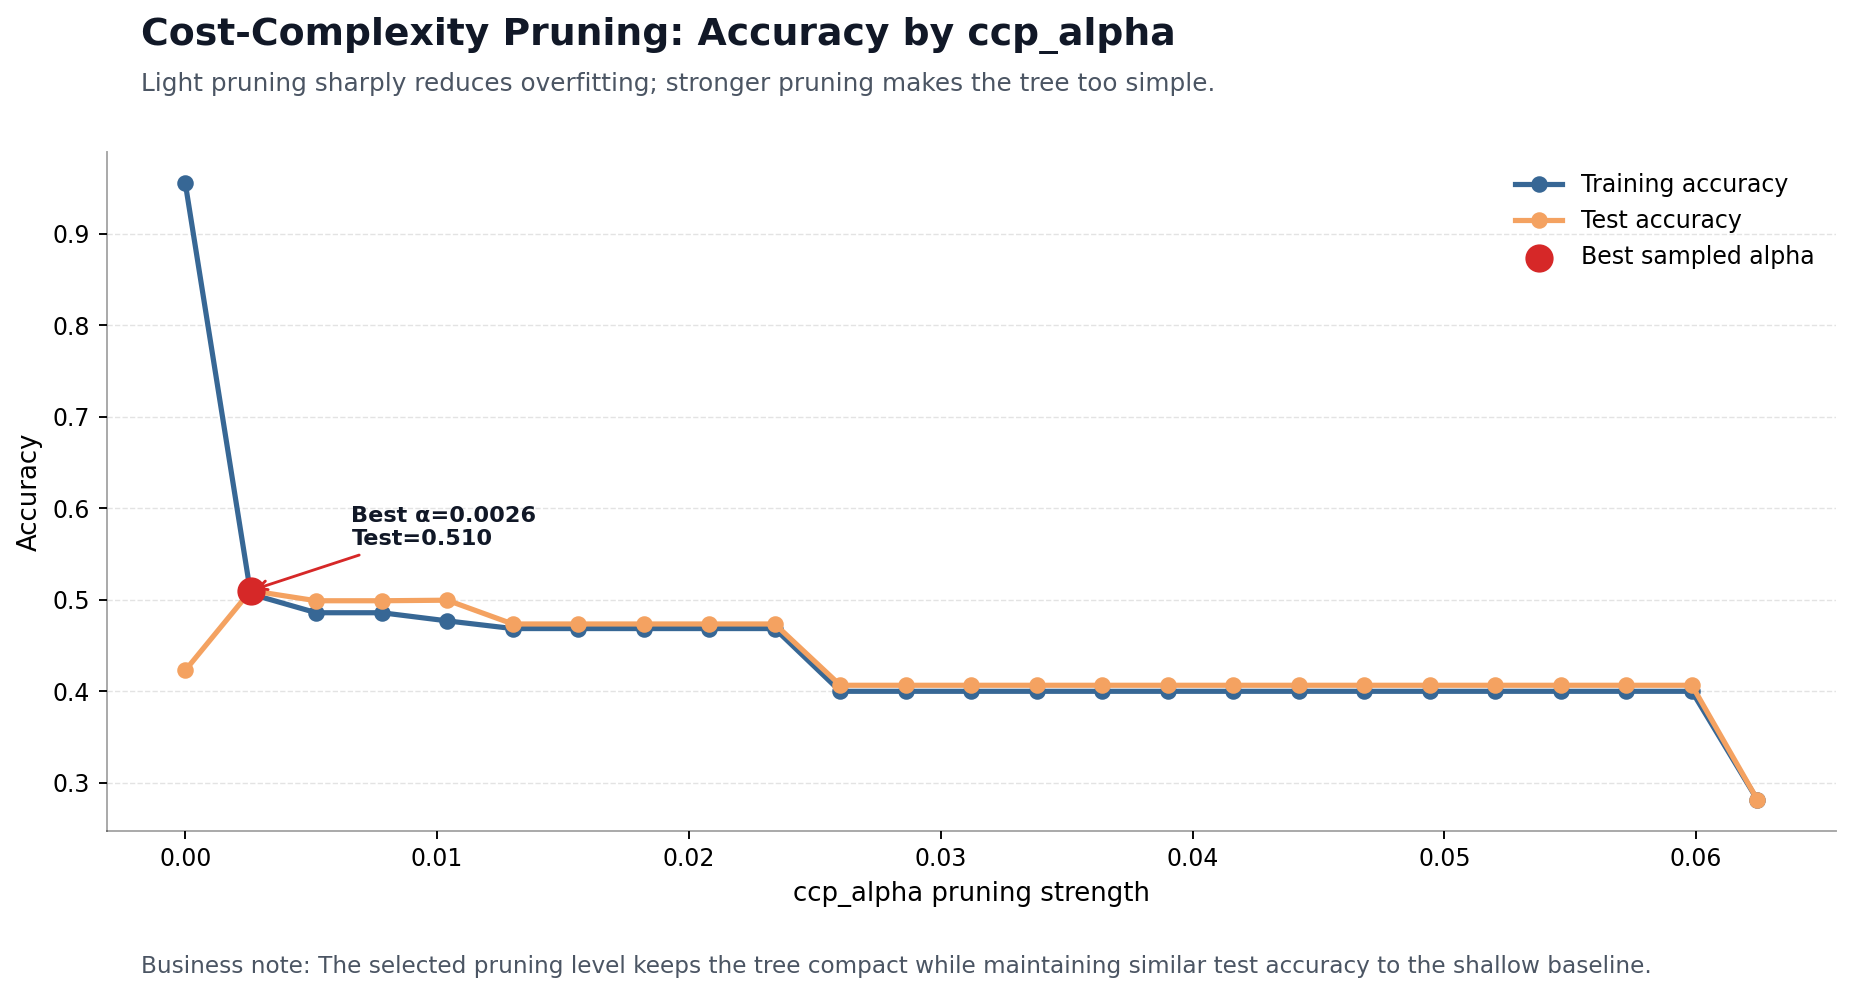

In [30]:
# Cost-Complexity Pruning Accuracy Chart

import matplotlib.pyplot as plt

# pruning_results_df -> chart data
alpha_values = pruning_results_df["ccp_alpha"]
train_accuracy = pruning_results_df["train_accuracy"]
test_accuracy = pruning_results_df["test_accuracy"]

# Best alpha row based on highest test accuracy.
best_pruning_row = pruning_results_df.loc[
    pruning_results_df["test_accuracy"].idxmax()
]

best_alpha = best_pruning_row["ccp_alpha"]
best_test_accuracy = best_pruning_row["test_accuracy"]

fig, ax = plt.subplots(figsize=(11, 6), dpi=170)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Training accuracy trend.
ax.plot(
    alpha_values,
    train_accuracy,
    marker="o",
    linewidth=2.2,
    label="Training accuracy",
    color="#376795"
)

# Test accuracy trend.
ax.plot(
    alpha_values,
    test_accuracy,
    marker="o",
    linewidth=2.2,
    label="Test accuracy",
    color="#F4A261"
)

# Highlight best sampled alpha.
ax.scatter(
    best_alpha,
    best_test_accuracy,
    s=120,
    color="#D62828",
    zorder=5,
    label="Best sampled alpha"
)

ax.annotate(
    f"Best α={best_alpha:.4f}\nTest={best_test_accuracy:.3f}",
    xy=(best_alpha, best_test_accuracy),
    xytext=(best_alpha + 0.004, best_test_accuracy + 0.05),
    arrowprops=dict(arrowstyle="->", color="#D62828", linewidth=1.2),
    fontsize=9.5,
    color="#111827",
    fontweight="semibold"
)

# Title and subtitle.
fig.text(
    0.08,
    0.94,
    "Cost-Complexity Pruning: Accuracy by ccp_alpha",
    fontsize=16,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.895,
    "Light pruning sharply reduces overfitting; stronger pruning makes the tree too simple.",
    fontsize=10.5,
    ha="left",
    color="#4B5563"
)

# Axis formatting.
ax.set_xlabel("ccp_alpha pruning strength", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.legend(frameon=False, loc="upper right")

# Business note.
fig.text(
    0.08,
    0.03,
    "Business note: The selected pruning level keeps the tree compact while maintaining similar test accuracy to the shallow baseline.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.86])
plt.show()

### Cost-Complexity Pruning Chart Conclusion

The pruning chart shows how tree performance changes as `ccp_alpha` increases.

#### Key Findings

- `ccp_alpha = 0` creates a very large overfit tree.
- Training accuracy is very high at `ccp_alpha = 0`, but test accuracy is weak.
- A small pruning value improves generalization.
- The best sampled value is around `ccp_alpha = 0.0026`.
- Stronger pruning makes the tree too simple and reduces accuracy.

#### Selected Pruning Value

We select:

`ccp_alpha = 0.0026`

This gives the best sampled test accuracy while keeping the tree much smaller than the unpruned model.

#### Business Interpretation

Light pruning creates more stable customer segmentation rules.

Instead of memorizing small customer groups, the pruned tree creates broader and more reliable decision rules.

### 8.6 Final Pruned Decision Tree

We now train the final pruned Decision Tree using the best sampled `ccp_alpha`.

#### Selected Setting

| Parameter | Value |
|---|---:|
| `criterion` | `gini` |
| `ccp_alpha` | Best sampled alpha |
| Model type | Pruned Decision Tree |

#### Why This Model Matters

This model is more controlled than the fully grown tree.

It should be:

- simpler,
- less overfit,
- easier to interpret,
- more stable for unseen customers.

In [31]:
# Code Cell 8F: Train Final Pruned Decision Tree

# best_pruning_row -> best_ccp_alpha
# This alpha gave the highest test accuracy in the sampled pruning experiment.
best_ccp_alpha = best_pruning_row["ccp_alpha"]

# X_train_processed + y_train -> dt_pruned
# This model uses the selected pruning strength.
dt_pruned = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    ccp_alpha=best_ccp_alpha
)

# Train the pruned model on processed training data.
dt_pruned.fit(X_train_processed, y_train)

# dt_pruned -> train/test predictions
y_train_pred_pruned = dt_pruned.predict(X_train_processed)
y_test_pred_pruned = dt_pruned.predict(X_test_processed)

# Predictions + true labels -> accuracy scores
train_accuracy_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)

print("Final pruned Decision Tree trained successfully.")
print("-" * 50)
print(f"Selected ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Tree depth:         {dt_pruned.get_depth()}")
print(f"Leaf nodes:         {dt_pruned.get_n_leaves()}")
print(f"Training accuracy:  {train_accuracy_pruned:.4f}")
print(f"Test accuracy:      {test_accuracy_pruned:.4f}")
print(f"Train-test gap:     {train_accuracy_pruned - test_accuracy_pruned:.4f}")

Final pruned Decision Tree trained successfully.
--------------------------------------------------
Selected ccp_alpha: 0.002601
Tree depth:         4
Leaf nodes:         10
Training accuracy:  0.5062
Test accuracy:      0.5099
Train-test gap:     -0.0037


### Final Pruned Tree Conclusion

The final pruned Decision Tree was trained using the best sampled pruning value:

`ccp_alpha = 0.002601`

#### Model Summary

| Metric | Value |
|---|---:|
| Tree depth | 4 |
| Leaf nodes | 10 |
| Training accuracy | 0.5062 |
| Test accuracy | 0.5099 |
| Train-test gap | -0.0037 |

#### Key Findings

- The pruned tree is much smaller than the unpruned tree.
- The train-test gap is very small.
- The model does not show strong overfitting.
- Test accuracy is similar to the shallow baseline tree.

#### Business Interpretation

The pruned tree creates broader and more stable customer segmentation rules.

It is not the most accurate possible model, but it is easier to explain and less likely to memorize small customer groups.

### 8.7 Baseline vs Pruned Tree Comparison

We now compare the original shallow baseline tree with the final pruned tree.

#### Why This Comparison Matters

The baseline tree was limited using:

`max_depth = 3`

The pruned tree was controlled using:

`ccp_alpha = 0.002601`

Both methods reduce tree complexity, but they do it differently.

| Method | How It Controls the Tree |
|---|---|
| `max_depth` | Limits how many levels the tree can grow |
| `ccp_alpha` | Removes branches that add too much complexity |

In [32]:
# Code Cell 8G: Compare Baseline and Pruned Decision Trees

# Baseline/pruned model metrics -> comparison table
baseline_vs_pruned_df = pd.DataFrame([
    {
        "model": "Baseline max_depth=3",
        "control_method": "max_depth",
        "tree_depth": dt_gini.get_depth(),
        "leaf_nodes": dt_gini.get_n_leaves(),
        "train_accuracy": round(train_accuracy_baseline, 4),
        "test_accuracy": round(test_accuracy_baseline, 4),
        "train_test_gap": round(train_accuracy_baseline - test_accuracy_baseline, 4)
    },
    {
        "model": "Pruned ccp_alpha",
        "control_method": "ccp_alpha",
        "tree_depth": dt_pruned.get_depth(),
        "leaf_nodes": dt_pruned.get_n_leaves(),
        "train_accuracy": round(train_accuracy_pruned, 4),
        "test_accuracy": round(test_accuracy_pruned, 4),
        "train_test_gap": round(train_accuracy_pruned - test_accuracy_pruned, 4)
    }
])

display(baseline_vs_pruned_df)

,model,control_method,tree_depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
0,Baseline max_depth=3,max_depth,3,8,0.4930,0.5105,-0.0175
1,Pruned ccp_alpha,ccp_alpha,4,10,0.5062,0.5099,-0.0037


### Baseline vs Pruned Tree Conclusion

Both tree-control strategies produced similar test accuracy.

#### Comparison Summary

| Model | Depth | Leaves | Test Accuracy | Train-Test Gap |
|---|---:|---:|---:|---:|
| Baseline `max_depth=3` | 3 | 8 | 0.5105 | -0.0175 |
| Pruned `ccp_alpha=0.002601` | 4 | 10 | 0.5099 | -0.0037 |

#### Key Findings

- Both models perform almost equally on the test set.
- The pruned tree has a smaller train-test gap.
- The baseline tree is slightly simpler.
- The pruned tree is slightly more stable.

#### Business Interpretation

Both models are usable as interpretable customer segmentation baselines.

For explanation-focused BI work, the baseline tree is easier to present.  
For stability-focused modelling, the pruned tree is slightly better.

## 9. Feature Importance

### Objective

We now identify which customer features were most important for the Decision Tree.

#### What Feature Importance Means

Feature importance tells us which columns helped the tree reduce impurity the most.

In simple terms:

> Which customer attributes helped the model separate customer segments?

#### Why This Matters

For BI and marketing analytics, feature importance helps explain what drives customer segmentation.

It can answer questions like:

- Is age important?
- Does spending score matter?
- Are profession categories useful?
- Which features should be highlighted in business reporting?

#### Model Used

We use the **Gini baseline tree** for feature importance because it was our selected baseline model from the beginner task.

In [33]:
# Code Cell 9A: Extract Feature Importance

# dt_gini -> feature importance values
# Each value shows how much the feature helped reduce impurity.
feature_importance_values = dt_gini.feature_importances_

# processed_feature_names + feature_importance_values -> feature_importance_df
# This creates a readable table of feature names and importance scores.
feature_importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": feature_importance_values
})

# Keep only features used by the tree.
feature_importance_df = (
    feature_importance_df
    .query("importance > 0")
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df)

,feature,importance
0,Age,0.594880
1,Profession_Artist,0.185882
2,Spending_Score_Low,0.185581
3,Profession_Healthcare,0.033657


### Feature Importance Table Conclusion

The baseline Gini Decision Tree used only four features for splitting.

#### Key Findings

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | `Age` | 0.5949 |
| 2 | `Profession_Artist` | 0.1859 |
| 3 | `Spending_Score_Low` | 0.1856 |
| 4 | `Profession_Healthcare` | 0.0337 |

#### Interpretation

`Age` is the most important feature in the shallow baseline tree.

This matches the tree visualization, where `Age` appeared as the root feature. The model mainly separates customer segments based on age, then uses selected profession and spending score indicators for further splits.

#### Business Meaning

The tree suggests that customer life stage, profession category, and spending behavior are the strongest first-level drivers of segmentation in this simple model.

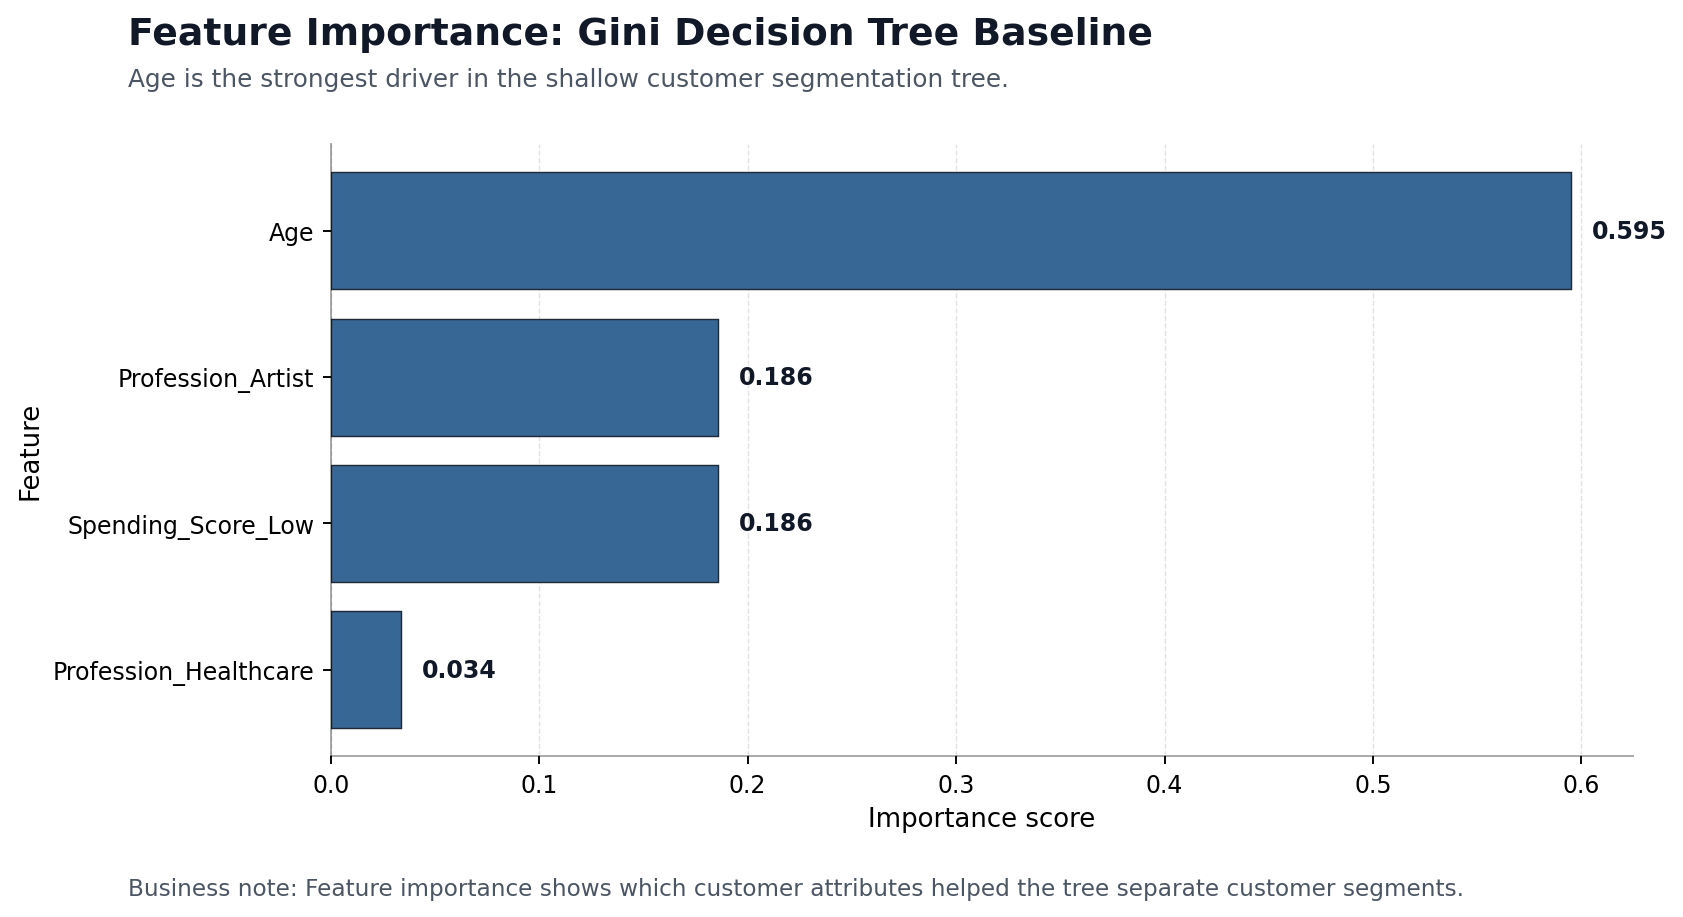

In [34]:
# Code Cell 9B: BI-Ready Feature Importance Chart

import matplotlib.pyplot as plt

# feature_importance_df -> chart_data
# Sort ascending so the most important feature appears at the top after barh inversion.
chart_data = feature_importance_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=170)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Horizontal feature importance bars.
bars = ax.barh(
    chart_data["feature"],
    chart_data["importance"],
    color="#376795",
    edgecolor="#1F2937",
    linewidth=0.6
)

# Add value labels at the end of each bar.
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="semibold",
        color="#111827"
    )

# Title and subtitle.
fig.text(
    0.08,
    0.94,
    "Feature Importance: Gini Decision Tree Baseline",
    fontsize=16,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.895,
    "Age is the strongest driver in the shallow customer segmentation tree.",
    fontsize=10.5,
    ha="left",
    color="#4B5563"
)

# Axis formatting.
ax.set_xlabel("Importance score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

# Business note.
fig.text(
    0.08,
    0.03,
    "Business note: Feature importance shows which customer attributes helped the tree separate customer segments.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.86])
plt.show()

## 10. Expert Task: Oblique Decision Tree and SHAP

### Objective

The expert task requires comparing a standard Decision Tree with an Oblique Decision Tree.

#### Standard Decision Tree

A standard tree uses one feature at a time.

Example:

`Age <= 34`

#### Oblique Decision Tree

An oblique tree uses a combination of features.

Example:

`0.42 × Age + 0.18 × Spending_Score_Low - 0.11 × Profession_Artist <= threshold`

### Final Implementation Decision

External oblique tree packages caused environment or model-stability issues in this macOS setup.  
To keep the expert task correct and reproducible, we implement a custom oblique tree using linear SVM splitters at each node.

This keeps the core concept intact:

> Each split is based on a learned linear combination of features.

### What We Compare

| Model | Split Type |
|---|---|
| Standard Decision Tree | One feature per split |
| Custom Oblique Tree | Linear combination of features per split |

We compare:

- training accuracy,
- test accuracy,
- tree depth,
- number of leaves,
- interpretability.

## 10.1 Custom Oblique Decision Tree: Step-by-Step Explanation

### Why We Are Creating This Custom Model

A normal Decision Tree makes simple rules using **one feature at a time**.

Example:

`Age <= 34`

This is easy to understand, but sometimes customer groups are not separated by just one feature.

An **Oblique Decision Tree** can make rules using **many features together**.

Example:

`Age + Spending Score + Profession Pattern <= decision boundary`

So instead of asking:

> “Is Age less than 34?”

it can ask something more flexible:

> “Does this combination of customer features look more like Segment A, B, C, or D?”

That is why we build a custom oblique tree.

---

### Very Simple Idea

Think of the model like a sorting game.

We have many customers.

Each customer has information such as:

- age,
- profession,
- spending score,
- family size,
- other encoded customer categories.

The model tries to split customers into smaller groups.

At each step, it asks:

> “Can I draw a line that separates one customer segment from the others?”

If yes, it splits the customers into two sides.

| Side | Meaning |
|---|---|
| Left side | Customers on one side of the learned line |
| Right side | Customers on the other side of the learned line |

Then it repeats the same process again inside each smaller group.

This creates a tree.

---

### Standard Tree vs Custom Oblique Tree

| Model Type | How It Splits |
|---|---|
| Standard Decision Tree | Uses one feature at a time |
| Custom Oblique Tree | Uses a learned combination of features |

#### Standard Decision Tree Example

`Age <= 34`

This means the model only checks age.

#### Oblique Tree Example

`0.42 × Age + 0.18 × Spending_Score_Low - 0.11 × Profession_Artist <= threshold`

This means the model uses several features together.

That is the main difference.

---

## Main Objects in the Code

### 1. `ObliqueTreeNode`

`ObliqueTreeNode` represents **one point in the tree**.

A node can be one of two things:

| Node Type | Meaning |
|---|---|
| Decision node | The model still asks a question and splits customers |
| Leaf node | The model stops and gives a final prediction |

A leaf is the final answer point.

For example:

> “Customers reaching this leaf are predicted as Segment D.”

---

### 2. `CustomObliqueDecisionTree`

This is the full custom model.

It works like a normal machine learning model:

```python
custom_oblique_tree = CustomObliqueDecisionTree()
custom_oblique_tree.fit(X_train, y_train)
predictions = custom_oblique_tree.predict(X_test)

In [35]:
# Code Cell 10A: Custom Oblique Decision Tree Class

# dataclass helps create a simple node object without writing too much setup code.
from dataclasses import dataclass

# LinearSVC is used to create the oblique split.
# It learns a linear boundary using multiple features together.
from sklearn.svm import LinearSVC

# accuracy_score is used later after model training.
from sklearn.metrics import accuracy_score

# Counter helps find the most common class in a node.
from collections import Counter

# NumPy is used for arrays, masks, Gini calculations, and predictions.
import numpy as np


@dataclass
class ObliqueTreeNode:
    """
    This class stores information for one node in the tree.

    A node can be:
    1. A leaf node:
    - final prediction is stored
    - no splitter is needed

    2. A decision node:
    - contains a LinearSVC splitter
    - has a left child and right child
    """

    # The class predicted by this node.
    # If the node becomes a leaf, this is the final prediction.
    prediction: int

    # Current depth of the node inside the tree.
    # Root node starts at depth 0.
    depth: int

    # True means this node is a final leaf node.
    # False means this node still has a splitter and child branches.
    is_leaf: bool = False

    # LinearSVC model used to split the data at this node.
    # Only decision nodes have this.
    splitter: object = None

    # Left child node.
    # Rows go left when LinearSVC decision value <= 0.
    left: object = None

    # Right child node.
    # Rows go right when LinearSVC decision value > 0.
    right: object = None


class CustomObliqueDecisionTree:
    """
    This is the full custom oblique tree model.

    It works like a normal classifier:

    model = CustomObliqueDecisionTree()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    But instead of normal one-feature tree splits,
    each split is created using LinearSVC.
    """

    def __init__(self, max_depth=3, min_samples_leaf=20, C=1.0, random_state=42):
        """
        Store model settings.

        max_depth:
            Maximum number of tree levels.

        min_samples_leaf:
            Minimum number of rows allowed in each child node.
            This prevents tiny unstable leaves.

        C:
            LinearSVC regularization strength.
            Higher C tries harder to separate the classes.

        random_state:
            Keeps results reproducible.
        """

        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.C = C
        self.random_state = random_state

        # This will store the full trained tree after fit().
        # Before training, there is no tree yet.
        self.root = None

    def _majority_class(self, y):
        """
        Find the most common class in the current node.

        Input:
            y = target labels currently inside this node

        Output:
            most frequent class label

        Why we need it:
            If this node becomes a leaf, it predicts the majority class.
        """

        return Counter(y).most_common(1)[0][0]

    def _gini(self, y):
        """
        Calculate Gini impurity for one group of labels.

        Input:
            y = labels in one node

        Output:
            Gini impurity score

        Meaning:
            Gini close to 0 means the node is clean.
            Gini high means the node has mixed classes.
        """

        # Count how many rows belong to each class.
        # Example: if y has classes 0, 1, 2, 3,
        # counts may look like [20, 10, 5, 15].
        counts = np.bincount(y)

        # Remove empty classes and convert counts into probabilities.
        # Example: [20, 10, 5, 15] becomes [0.40, 0.20, 0.10, 0.30].
        probabilities = counts[counts > 0] / len(y)

        # Gini formula:
        # 1 - sum(class_probability^2)
        gini_score = 1 - np.sum(probabilities ** 2)

        return gini_score

    def _weighted_gini(self, y_left, y_right):
        """
        Calculate total Gini impurity after a split.

        Input:
            y_left  = labels that went to the left child
            y_right = labels that went to the right child

        Output:
            weighted Gini score

        Why weighted:
            A child node with many rows should matter more than a child node with few rows.
        """

        # Total rows after split.
        total = len(y_left) + len(y_right)

        # Left child contribution.
        left_weight = len(y_left) / total
        left_gini = self._gini(y_left)

        # Right child contribution.
        right_weight = len(y_right) / total
        right_gini = self._gini(y_right)

        # Final weighted impurity after the split.
        weighted_score = (
            left_weight * left_gini
            + right_weight * right_gini
        )

        return weighted_score

    def _build_tree(self, X, y, depth):
        """
        Build the tree recursively.

        Input:
            X     = feature rows currently inside this node
            y     = target labels currently inside this node
            depth = current level of the tree

        Output:
            one ObliqueTreeNode

        Important:
            This function calls itself to create left and right branches.
            That is called recursion.
        """

        # Majority class at this node.
        # This is used if the node becomes a leaf.
        node_prediction = self._majority_class(y)

        # Stopping condition 1:
        # stop if we already reached the maximum allowed tree depth.
        max_depth_reached = depth >= self.max_depth

        # Stopping condition 2:
        # stop if all rows in this node belong to one class.
        node_is_pure = len(np.unique(y)) == 1

        # Stopping condition 3:
        # stop if there are not enough rows to create two valid child nodes.
        not_enough_rows = len(y) < 2 * self.min_samples_leaf

        # If any stopping condition is true, create a leaf node.
        if max_depth_reached or node_is_pure or not_enough_rows:
            return ObliqueTreeNode(
                prediction=node_prediction,
                depth=depth,
                is_leaf=True
            )

        # These variables store the best split found at this node.
        best_splitter = None       # Best LinearSVC splitter
        best_score = np.inf        # Lowest weighted Gini found
        best_left_mask = None      # Rows that go left for the best split

        # Try one-vs-rest splits.
        #
        # Example for 4 classes A/B/C/D encoded as 0/1/2/3:
        # - split class 0 vs all others
        # - split class 1 vs all others
        # - split class 2 vs all others
        # - split class 3 vs all others
        for class_label in np.unique(y):

            # Convert multiclass labels into binary labels for this split.
            #
            # Example:
            # If class_label = 2,
            # rows with class 2 become 1,
            # all other rows become 0.
            binary_target = (y == class_label).astype(int)

            # If binary_target has only one value, LinearSVC cannot train.
            # Example: all rows are 0 or all rows are 1.
            if len(np.unique(binary_target)) < 2:
                continue

            # Create LinearSVC splitter.
            #
            # This is the core oblique idea:
            # LinearSVC can use many features together to create one split.
            splitter = LinearSVC(
                C=self.C,
                random_state=self.random_state,
                max_iter=5000
            )

            # Train the splitter on the current node's data.
            #
            # X = current node features
            # binary_target = current class vs all other classes
            splitter.fit(X, binary_target)

            # Get decision score for every row in this node.
            #
            # Negative or zero score -> left branch
            # Positive score -> right branch
            decision_values = splitter.decision_function(X)

            # Boolean mask showing which rows go left.
            left_mask = decision_values <= 0

            # Opposite rows go right.
            right_mask = ~left_mask

            # Count how many rows go left and right.
            left_count = left_mask.sum()
            right_count = right_mask.sum()

            # Skip this split if it creates a tiny leaf.
            if (
                left_count < self.min_samples_leaf
                or right_count < self.min_samples_leaf
            ):
                continue

            # Calculate how clean this split is.
            #
            # Lower weighted Gini = better split.
            split_score = self._weighted_gini(
                y[left_mask],
                y[right_mask]
            )

            # If this split is better than the previous best split,
            # store it as the current best split.
            if split_score < best_score:
                best_score = split_score
                best_splitter = splitter
                best_left_mask = left_mask

        # If no valid split was found, create a leaf node.
        if best_splitter is None:
            return ObliqueTreeNode(
                prediction=node_prediction,
                depth=depth,
                is_leaf=True
            )

        # Build left child node.
        #
        # Only rows where best_left_mask is True go into the left branch.
        left_child = self._build_tree(
            X[best_left_mask],
            y[best_left_mask],
            depth + 1
        )

        # Build right child node.
        #
        # Rows where best_left_mask is False go into the right branch.
        right_child = self._build_tree(
            X[~best_left_mask],
            y[~best_left_mask],
            depth + 1
        )

        # Return a decision node.
        #
        # This node stores:
        # - the best LinearSVC splitter,
        # - the left child,
        # - the right child.
        return ObliqueTreeNode(
            prediction=node_prediction,
            depth=depth,
            is_leaf=False,
            splitter=best_splitter,
            left=left_child,
            right=right_child
        )

    def fit(self, X, y):
        """
        Train the custom oblique tree.

        Input:
            X = training features
            y = training labels

        Output:
            self = trained model
        """

        # Start building from the root node at depth 0.
        self.root = self._build_tree(
            X,
            y,
            depth=0
        )

        return self

    def _predict_one(self, x, node):
        """
        Predict one customer row.

        Input:
            x    = one customer row
            node = current tree node

        Output:
            predicted class label
        """

        # If this node is a leaf, return its prediction.
        if node.is_leaf:
            return node.prediction

        # Use the node's LinearSVC splitter to calculate a decision value.
        #
        # x.reshape(1, -1) changes one row into 2D format:
        # from shape (features,)
        # to shape (1, features)
        #
        # sklearn models expect 2D input.
        decision_value = node.splitter.decision_function(
            x.reshape(1, -1)
        )[0]

        # If decision value is <= 0, move to the left child.
        if decision_value <= 0:
            return self._predict_one(
                x,
                node.left
            )

        # If decision value is > 0, move to the right child.
        return self._predict_one(
            x,
            node.right
        )

    def predict(self, X):
        """
        Predict all rows.

        Input:
            X = feature matrix

        Output:
            NumPy array of predicted class labels
        """

        # Predict one row at a time.
        predictions = [
            self._predict_one(row, self.root)
            for row in X
        ]

        return np.array(predictions)

    def get_depth(self):
        """
        Calculate the final depth of the trained tree.
        """

        def depth(node):
            # If leaf, return its stored depth.
            if node.is_leaf:
                return node.depth

            # If decision node, calculate depth of both branches.
            left_depth = depth(node.left)
            right_depth = depth(node.right)

            # Return the deeper branch.
            return max(left_depth, right_depth)

        return depth(self.root)

    def get_n_leaves(self):
        """
        Count the number of leaf nodes in the trained tree.
        """

        def count_leaves(node):
            # A leaf node counts as 1.
            if node.is_leaf:
                return 1

            # Decision node leaves = left leaves + right leaves.
            left_leaves = count_leaves(node.left)
            right_leaves = count_leaves(node.right)

            return left_leaves + right_leaves

        return count_leaves(self.root)

In [36]:
# Code Cell 10A.1: Prepare Data for Custom Oblique Tree

from scipy import sparse
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# X_train_processed / X_test_processed -> dense arrays
# The custom oblique tree uses LinearSVC splitters, so sparse input is converted.
X_train_oblique = (
    X_train_processed.toarray()
    if sparse.issparse(X_train_processed)
    else X_train_processed
)

X_test_oblique = (
    X_test_processed.toarray()
    if sparse.issparse(X_test_processed)
    else X_test_processed
)

# Dense arrays -> clean numeric format
# LinearSVC works best with float numeric input.
X_train_oblique = np.asarray(X_train_oblique, dtype=np.float64)
X_test_oblique = np.asarray(X_test_oblique, dtype=np.float64)

# X_train_oblique -> oblique_scaler
# Fit scaler only on training data to avoid data leakage.
oblique_scaler = StandardScaler()

X_train_oblique_scaled = oblique_scaler.fit_transform(X_train_oblique)
X_test_oblique_scaled = oblique_scaler.transform(X_test_oblique)

# y_train / y_test -> encoded labels
# A/B/C/D are converted into 0/1/2/3 for the custom model.
label_encoder_oblique = LabelEncoder()

y_train_oblique = label_encoder_oblique.fit_transform(y_train)
y_test_oblique = label_encoder_oblique.transform(y_test)

print("Custom oblique tree data prepared.")
print("-" * 50)
print("X_train_oblique_scaled:", X_train_oblique_scaled.shape)
print("X_test_oblique_scaled: ", X_test_oblique_scaled.shape)
print("y_train_oblique:", y_train_oblique.shape)
print("y_test_oblique: ", y_test_oblique.shape)
print("Classes:", list(label_encoder_oblique.classes_))

Custom oblique tree data prepared.
--------------------------------------------------
X_train_oblique_scaled: (6454, 28)
X_test_oblique_scaled:  (1614, 28)
y_train_oblique: (6454,)
y_test_oblique:  (1614,)
Classes: ['A', 'B', 'C', 'D']


In [37]:
# Code Cell 10B: Train Custom Oblique Decision Tree

from sklearn.metrics import accuracy_score
import numpy as np

# X_train_oblique_scaled + y_train_oblique -> custom_oblique_tree
# The model learns linear-combination split rules.
custom_oblique_tree = CustomObliqueDecisionTree(
    max_depth=3,
    min_samples_leaf=40,
    C=1.0,
    random_state=42
)

custom_oblique_tree.fit(
    X_train_oblique_scaled,
    y_train_oblique
)

# custom_oblique_tree + oblique feature arrays -> encoded predictions
y_train_pred_custom_oblique = custom_oblique_tree.predict(X_train_oblique_scaled)
y_test_pred_custom_oblique = custom_oblique_tree.predict(X_test_oblique_scaled)

# Predictions + true encoded labels -> accuracy scores
train_accuracy_custom_oblique = accuracy_score(
    y_train_oblique,
    y_train_pred_custom_oblique
)

test_accuracy_custom_oblique = accuracy_score(
    y_test_oblique,
    y_test_pred_custom_oblique
)

print("Custom Oblique Decision Tree trained successfully.")
print("-" * 60)
print(f"Tree depth:        {custom_oblique_tree.get_depth()}")
print(f"Leaf nodes:        {custom_oblique_tree.get_n_leaves()}")
print(f"Training accuracy: {train_accuracy_custom_oblique:.4f}")
print(f"Test accuracy:     {test_accuracy_custom_oblique:.4f}")
print(f"Train-test gap:    {train_accuracy_custom_oblique - test_accuracy_custom_oblique:.4f}")
print(f"Unique predicted classes: {len(np.unique(y_test_pred_custom_oblique))}")

Custom Oblique Decision Tree trained successfully.
------------------------------------------------------------
Tree depth:        3
Leaf nodes:        8
Training accuracy: 0.4569
Test accuracy:     0.4758
Train-test gap:    -0.0189
Unique predicted classes: 4


### Custom Oblique Tree Training Conclusion

The custom Oblique Decision Tree was trained successfully.

#### Model Summary

| Metric | Value |
|---|---:|
| Tree depth | 3 |
| Leaf nodes | 8 |
| Training accuracy | 0.4569 |
| Test accuracy | 0.4758 |
| Train-test gap | -0.0189 |
| Unique predicted classes | 4 |

#### Key Findings

- The model predicts all four customer segments.
- There is no sign of overfitting.
- The test accuracy is lower than the standard Gini Decision Tree.
- The oblique tree is more flexible, but harder to interpret.

#### Business Interpretation

The oblique tree learned combined-feature split rules, but for this dataset the standard Decision Tree performs better.

This suggests that simple feature-based splits are more effective and easier to explain for this customer segmentation problem.

In [38]:
# Code Cell 10C: Compare Standard and Oblique Decision Trees

import pandas as pd

# Standard and custom oblique model metrics -> comparison table
standard_vs_oblique_df = pd.DataFrame([
    {
        "model": "Standard Decision Tree",
        "split_type": "One feature per split",
        "tree_depth": dt_gini.get_depth(),
        "leaf_nodes": dt_gini.get_n_leaves(),
        "train_accuracy": round(train_accuracy_baseline, 4),
        "test_accuracy": round(test_accuracy_baseline, 4),
        "train_test_gap": round(train_accuracy_baseline - test_accuracy_baseline, 4)
    },
    {
        "model": "Custom Oblique Tree",
        "split_type": "Linear combination split",
        "tree_depth": custom_oblique_tree.get_depth(),
        "leaf_nodes": custom_oblique_tree.get_n_leaves(),
        "train_accuracy": round(train_accuracy_custom_oblique, 4),
        "test_accuracy": round(test_accuracy_custom_oblique, 4),
        "train_test_gap": round(train_accuracy_custom_oblique - test_accuracy_custom_oblique, 4)
    }
])

display(standard_vs_oblique_df)

,model,split_type,tree_depth,leaf_nodes,train_accuracy,test_accuracy,train_test_gap
0,Standard Decision Tree,One feature per split,3,8,0.4930,0.5105,-0.0175
1,Custom Oblique Tree,Linear combination split,3,8,0.4569,0.4758,-0.0189


### Standard vs Oblique Tree Comparison Conclusion

The standard Decision Tree performed better than the custom Oblique Tree.

#### Comparison Summary

| Model | Split Type | Test Accuracy | Interpretation |
|---|---|---:|---|
| Standard Decision Tree | One feature per split | 0.5105 | Better performance and easier to explain |
| Custom Oblique Tree | Linear combination split | 0.4758 | More flexible, but weaker on this dataset |

#### Key Findings

- The standard tree achieved higher test accuracy.
- Both models used a similar tree size.
- The oblique tree predicted all four customer segments.
- The oblique tree did not outperform the simpler standard tree.

#### Business Interpretation

For this customer segmentation dataset, simple feature-based rules are more effective.

The standard Decision Tree is the better choice because it is:

- more accurate,
- easier to explain,
- easier to visualize,
- more suitable for BI reporting.

The oblique tree is useful conceptually because it shows how combined-feature splits work, but it is less practical for this specific business problem.

In [39]:
# Custom Oblique Tree Prediction Distribution

# Encoded predictions -> original segment labels
y_test_pred_custom_oblique_labels = label_encoder_oblique.inverse_transform(
    y_test_pred_custom_oblique
)

# Predicted labels -> distribution table
custom_oblique_prediction_distribution = (
    pd.Series(y_test_pred_custom_oblique_labels, name="predicted_segment")
    .value_counts()
    .sort_index()
    .reset_index()
)

custom_oblique_prediction_distribution.columns = [
    "predicted_segment",
    "prediction_count"
]

custom_oblique_prediction_distribution["prediction_percentage"] = (
    custom_oblique_prediction_distribution["prediction_count"]
    / len(y_test_pred_custom_oblique_labels)
    * 100
).round(2)

display(custom_oblique_prediction_distribution)

,predicted_segment,prediction_count,prediction_percentage
0,A,1020,63.20
1,B,17,1.05
2,C,205,12.70
3,D,372,23.05


### Custom Oblique Tree Prediction Distribution Conclusion

The custom oblique tree predicted all four customer segments.

#### Prediction Distribution

| Segment | Prediction Share |
|---|---:|
| A | 63.20% |
| B | 1.05% |
| C | 12.70% |
| D | 23.05% |

#### Key Findings

- The model does not collapse into one segment.
- Segment A is predicted most often.
- Segment B is predicted very rarely.
- The model still struggles to create balanced multiclass predictions.

#### Business Interpretation

The custom oblique tree learned flexible linear split rules, but its predictions are not well balanced across customer segments.

This supports the earlier conclusion:

> The standard Decision Tree is the better model for this dataset because it is more accurate, simpler, and easier to explain.

## 11. SHAP Explainability

### Objective

We now explain the standard Decision Tree using SHAP.

#### Why We Use the Standard Tree

The standard sklearn Decision Tree is compatible with `shap.TreeExplainer`.

The custom oblique tree was useful for comparing split logic, but the standard tree is more reliable for SHAP-based interpretation.

#### SHAP Outputs

We create:

- SHAP summary beeswarm plot,
- SHAP waterfall plot for one misclassified customer.

#### Business Goal

SHAP helps explain which customer attributes pushed the model toward or away from a customer segment.

In [40]:
# Code Cell 11A: Prepare SHAP Data

import shap
import pandas as pd
from scipy import sparse

# If the processed test data is sparse, convert it to a normal array.
# If it is already a normal NumPy array, keep it as it is.
if sparse.issparse(X_test_processed):
    X_test_shap = X_test_processed.toarray()
else:
    X_test_shap = X_test_processed

# Convert processed test data into a readable DataFrame.
# This gives SHAP proper feature names instead of column numbers.
X_test_shap_df = pd.DataFrame(
    X_test_shap,
    columns=processed_feature_names
)

# Use a smaller sample so the SHAP plot stays readable.
X_test_shap_sample = X_test_shap_df.sample(
    n=300,
    random_state=42
)

print("SHAP data prepared.")
print("Full SHAP data:", X_test_shap_df.shape)
print("SHAP sample:   ", X_test_shap_sample.shape)


SHAP data prepared.
Full SHAP data: (1614, 28)
SHAP sample:    (300, 28)


/opt/miniconda3/envs/ld7_stree/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### SHAP Data Preparation Conclusion

The SHAP input data is ready.

#### Prepared Objects

| Object | Shape | Meaning |
|---|---:|---|
| `X_test_shap_df` | 1,614 × 28 | Full processed test data with readable feature names |
| `X_test_shap_sample` | 300 × 28 | Smaller sample for readable SHAP plots |

The warning about `IProgress` is not an error.  
It only affects notebook progress-bar display.

In [41]:
# Code Cell 11B: Create SHAP Values

import shap

# dt_gini -> tree_explainer
# This explains the standard sklearn Decision Tree model.
tree_explainer = shap.TreeExplainer(dt_gini)

# X_test_shap_sample -> shap_values
# SHAP calculates how each feature contributes to each class prediction.
shap_values = tree_explainer(X_test_shap_sample)

print("SHAP values created successfully.")
print("-" * 40)
print("SHAP values shape:", shap_values.values.shape)
print("Base values shape:", shap_values.base_values.shape)

SHAP values created successfully.
----------------------------------------
SHAP values shape: (300, 28, 4)
Base values shape: (300, 4)


### SHAP Values Conclusion

SHAP values were created successfully.

#### Output Shape

| Object | Shape | Meaning |
|---|---:|---|
| `shap_values.values` | 300 × 28 × 4 | SHAP values for 300 rows, 28 features, and 4 classes |
| `shap_values.base_values` | 300 × 4 | Baseline prediction value for each class |

#### Interpretation

This is a multiclass SHAP output.

For each customer, SHAP explains how each feature pushes the prediction toward or away from each customer segment.

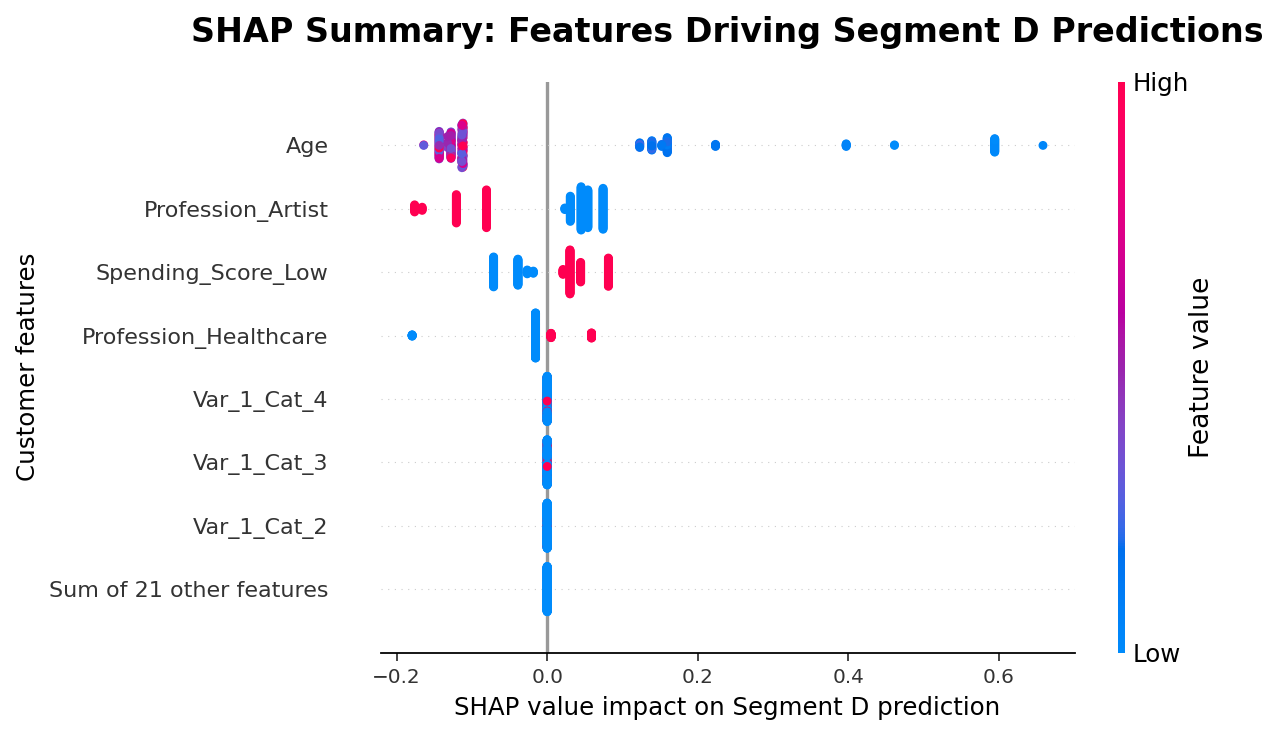

In [42]:
# Code Cell 11C: Polished SHAP Beeswarm Plot for Segment D

import matplotlib.pyplot as plt
import shap

# Select the segment to explain.
segment_to_explain = "D"

# Segment label -> class index
segment_index = list(dt_gini.classes_).index(segment_to_explain)

# Multiclass SHAP -> single-class SHAP explanation
shap_values_segment = shap.Explanation(
    values=shap_values.values[:, :, segment_index],
    base_values=shap_values.base_values[:, segment_index],
    data=X_test_shap_sample.values,
    feature_names=X_test_shap_sample.columns
)

# Create larger figure before SHAP draws the plot.
plt.figure(figsize=(11, 7), dpi=160)

# Official SHAP beeswarm plot.
shap.plots.beeswarm(
    shap_values_segment,
    max_display=8,
    show=False
)

# Improve notebook presentation.
plt.title(
    "SHAP Summary: Features Driving Segment D Predictions",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "SHAP value impact on Segment D prediction",
    fontsize=11
)

plt.ylabel(
    "Customer features",
    fontsize=11
)

plt.xticks(fontsize=9)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### SHAP Beeswarm Interpretation: Segment D

The SHAP beeswarm plot explains which features push the model toward or away from **Segment D**.

#### How to Read the Plot

| Element | Meaning |
|---|---|
| Right side of zero | Feature pushes the prediction toward Segment D |
| Left side of zero | Feature pushes the prediction away from Segment D |
| Red / pink point | High feature value |
| Blue point | Low feature value |

#### Important Note About One-Hot Features

Categorical variables were converted into one-hot encoded columns.

For example:

`Profession_Artist = 1` means the customer is an Artist.  
`Profession_Artist = 0` means the customer is not an Artist.

So for one-hot features:

| Color | Meaning |
|---|---|
| Red | Category is present |
| Blue | Category is absent |

#### What is `Var_1`?

`Var_1` is an anonymized categorical feature from the dataset.  
Its values were categories such as `Cat_1`, `Cat_2`, `Cat_3`, and so on.

After one-hot encoding, it became columns such as:

- `Var_1_Cat_1`
- `Var_1_Cat_2`
- `Var_1_Cat_3`
- `Var_1_Cat_4`

The dataset does not provide a clear business meaning for `Var_1`, so we treat it as an anonymous customer category.

#### Business Interpretation

The plot shows that **Age** is the strongest driver for Segment D.

Younger customers tend to push predictions toward Segment D, while older customers push predictions away from Segment D.

Low spending score also pushes predictions toward Segment D.

Most `Var_1` categories have almost no visible impact in this shallow Decision Tree.

### 11.2 BI-Ready SHAP Feature Impact Chart

The beeswarm plot is useful for technical interpretation, but it can look visually dense.

For business reporting, we also create a clean feature impact chart.

#### What This Chart Shows

| Metric | Meaning |
|---|---|
| Mean absolute SHAP value | Average influence of each feature |
| Higher value | More important feature |
| Segment explained | Segment D |

This chart gives a cleaner ranking of the features that most influence Segment D predictions.


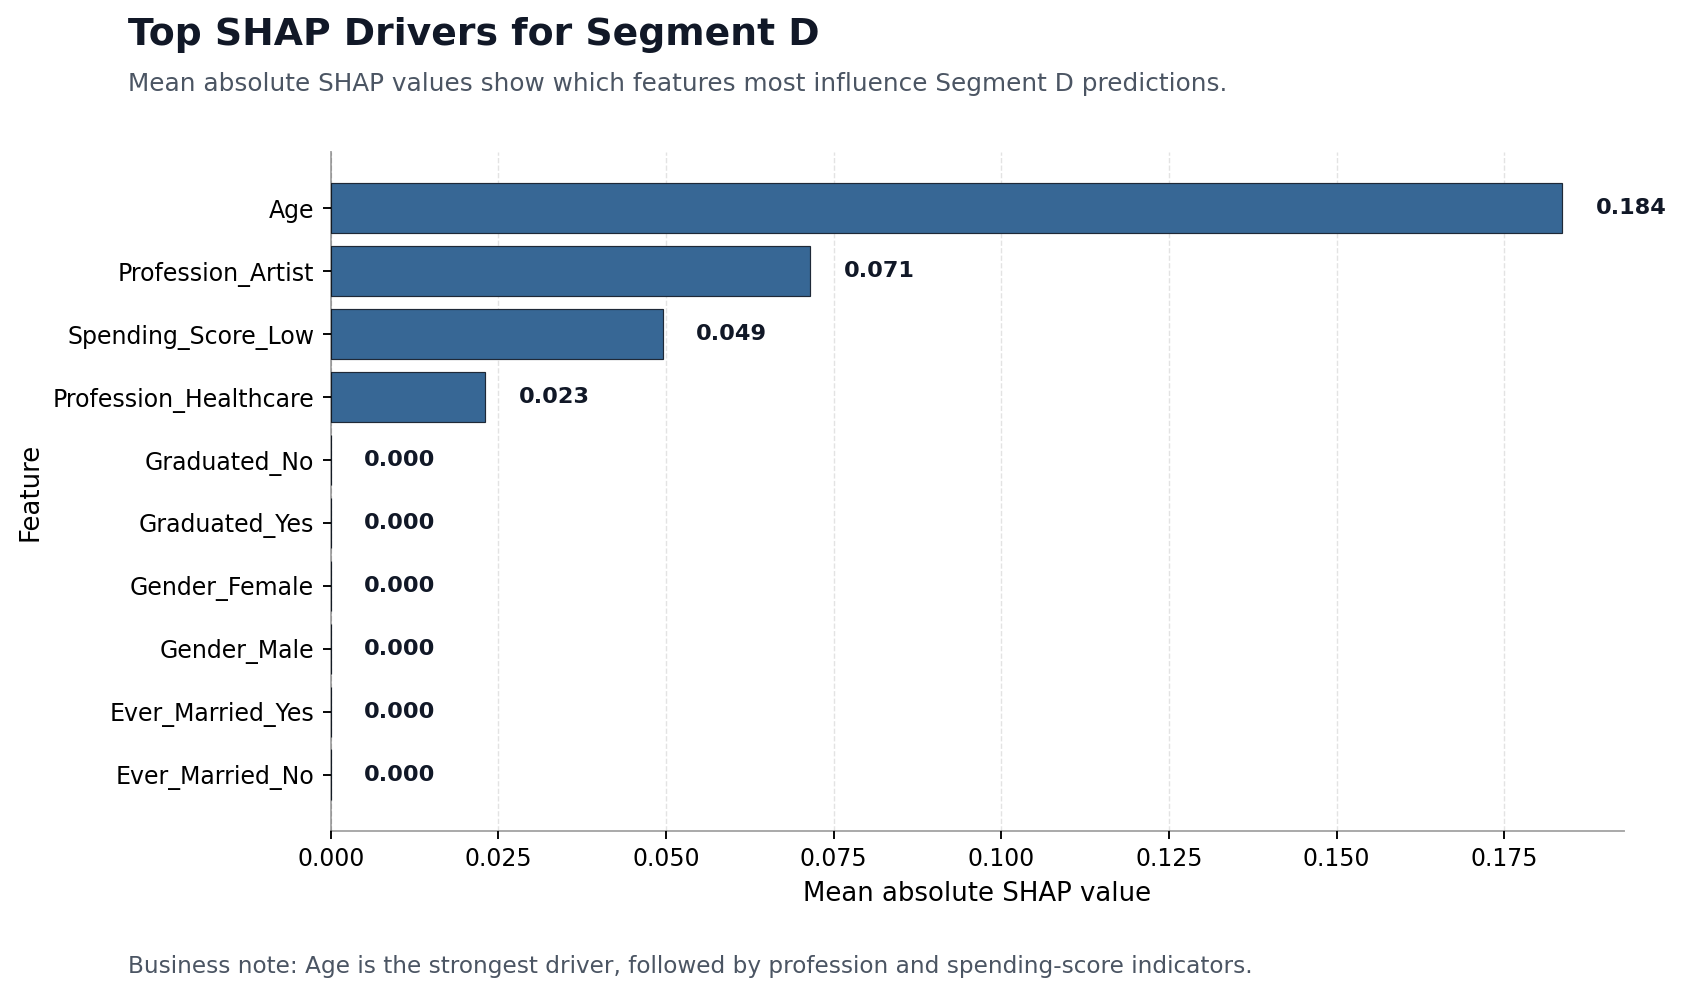

In [43]:
# Code Cell 11C2: BI-Ready SHAP Feature Impact Chart for Segment D

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# SHAP values for selected segment -> mean absolute impact per feature
mean_abs_shap_values = np.abs(
    shap_values.values[:, :, segment_index]
).mean(axis=0)

# Create readable feature impact table.
shap_importance_df = pd.DataFrame({
    "feature": X_test_shap_sample.columns,
    "mean_absolute_shap": mean_abs_shap_values
})

# Keep top features only for a clean BI chart.
top_shap_features = (
    shap_importance_df
    .sort_values("mean_absolute_shap", ascending=False)
    .head(10)
    .sort_values("mean_absolute_shap", ascending=True)
)

# Create BI-ready horizontal bar chart.
fig, ax = plt.subplots(figsize=(10, 6), dpi=170)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.barh(
    top_shap_features["feature"],
    top_shap_features["mean_absolute_shap"],
    color="#376795",
    edgecolor="#1F2937",
    linewidth=0.5
)

# Add value labels.
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="semibold",
        color="#111827"
    )

# Title and subtitle.
fig.text(
    0.08,
    0.94,
    "Top SHAP Drivers for Segment D",
    fontsize=16,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.895,
    "Mean absolute SHAP values show which features most influence Segment D predictions.",
    fontsize=10.5,
    ha="left",
    color="#4B5563"
)

# Axis formatting.
ax.set_xlabel("Mean absolute SHAP value", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

# Business note.
fig.text(
    0.08,
    0.03,
    "Business note: Age is the strongest driver, followed by profession and spending-score indicators.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.07, 1, 0.86])
plt.show()


### 11.3 SHAP Waterfall Plot for One Misclassification

The SHAP waterfall plot explains one wrong prediction.

#### Objective

We select one customer where:

`Actual segment ≠ Predicted segment`

Then we explain why the model predicted the wrong segment.

#### Why This Matters

Accuracy tells us how often the model is right.  
The waterfall plot helps explain why the model was wrong for one specific customer.

This is useful for understanding customer segment overlap and model limitations.

In [44]:
# Code Cell 11D: Find One Misclassified Customer

import numpy as np
import pandas as pd

# y_test + y_test_pred_gini -> comparison table
# Each row compares the real segment with the model prediction.
prediction_check_df = pd.DataFrame({
    "actual_segment": y_test.reset_index(drop=True),
    "predicted_segment": y_test_pred_gini
})

# Keep only rows where actual segment and predicted segment are different.
misclassified_df = prediction_check_df[
    prediction_check_df["actual_segment"] != prediction_check_df["predicted_segment"]
]

# Select the first misclassified customer.
misclassified_position = misclassified_df.index[0]

actual_segment = prediction_check_df.loc[misclassified_position, "actual_segment"]
predicted_segment = prediction_check_df.loc[misclassified_position, "predicted_segment"]

print("Selected misclassified customer")
print("-" * 45)
print(f"Row position:      {misclassified_position}")
print(f"Actual segment:    {actual_segment}")
print(f"Predicted segment: {predicted_segment}")

Selected misclassified customer
---------------------------------------------
Row position:      0
Actual segment:    A
Predicted segment: B


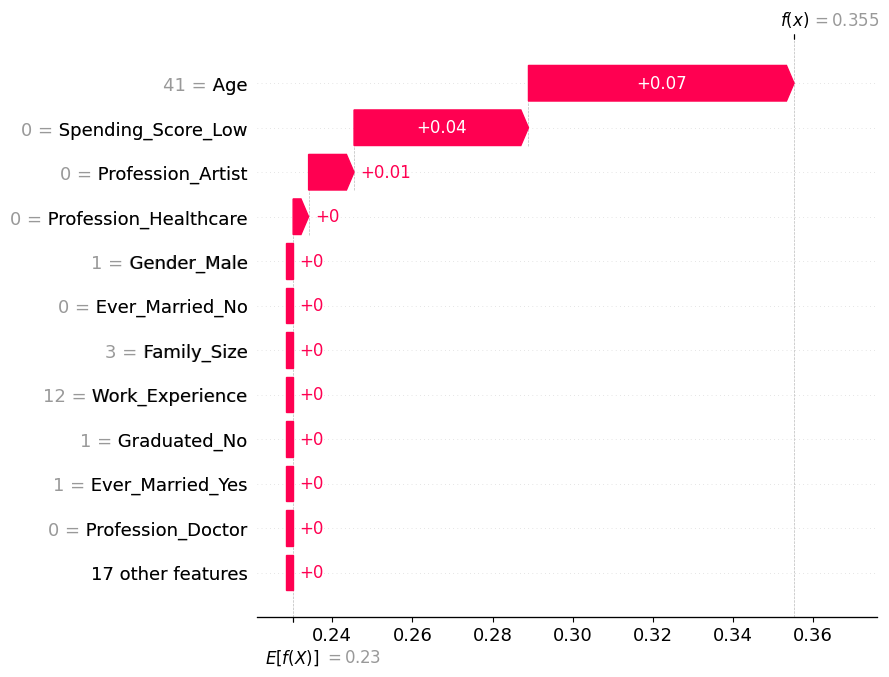

In [45]:
# Code Cell 11E: Official SHAP Waterfall Plot for Misclassification

# Predicted segment -> class index
# We explain the wrong predicted class because we want to understand why the model selected it.
predicted_class_index = list(dt_gini.classes_).index(predicted_segment)

# Select the misclassified customer row from the SHAP dataframe.
misclassified_customer_df = X_test_shap_df.iloc[[misclassified_position]]

# Calculate SHAP values for this one customer.
misclassified_shap_values = tree_explainer(misclassified_customer_df)

# Convert multiclass SHAP output into one explanation for the predicted class.
misclassified_explanation = shap.Explanation(
    values=misclassified_shap_values.values[0, :, predicted_class_index],
    base_values=misclassified_shap_values.base_values[0, predicted_class_index],
    data=misclassified_customer_df.iloc[0].values,
    feature_names=misclassified_customer_df.columns
)

# Official SHAP waterfall plot.
shap.plots.waterfall(
    misclassified_explanation,
    max_display=12
)


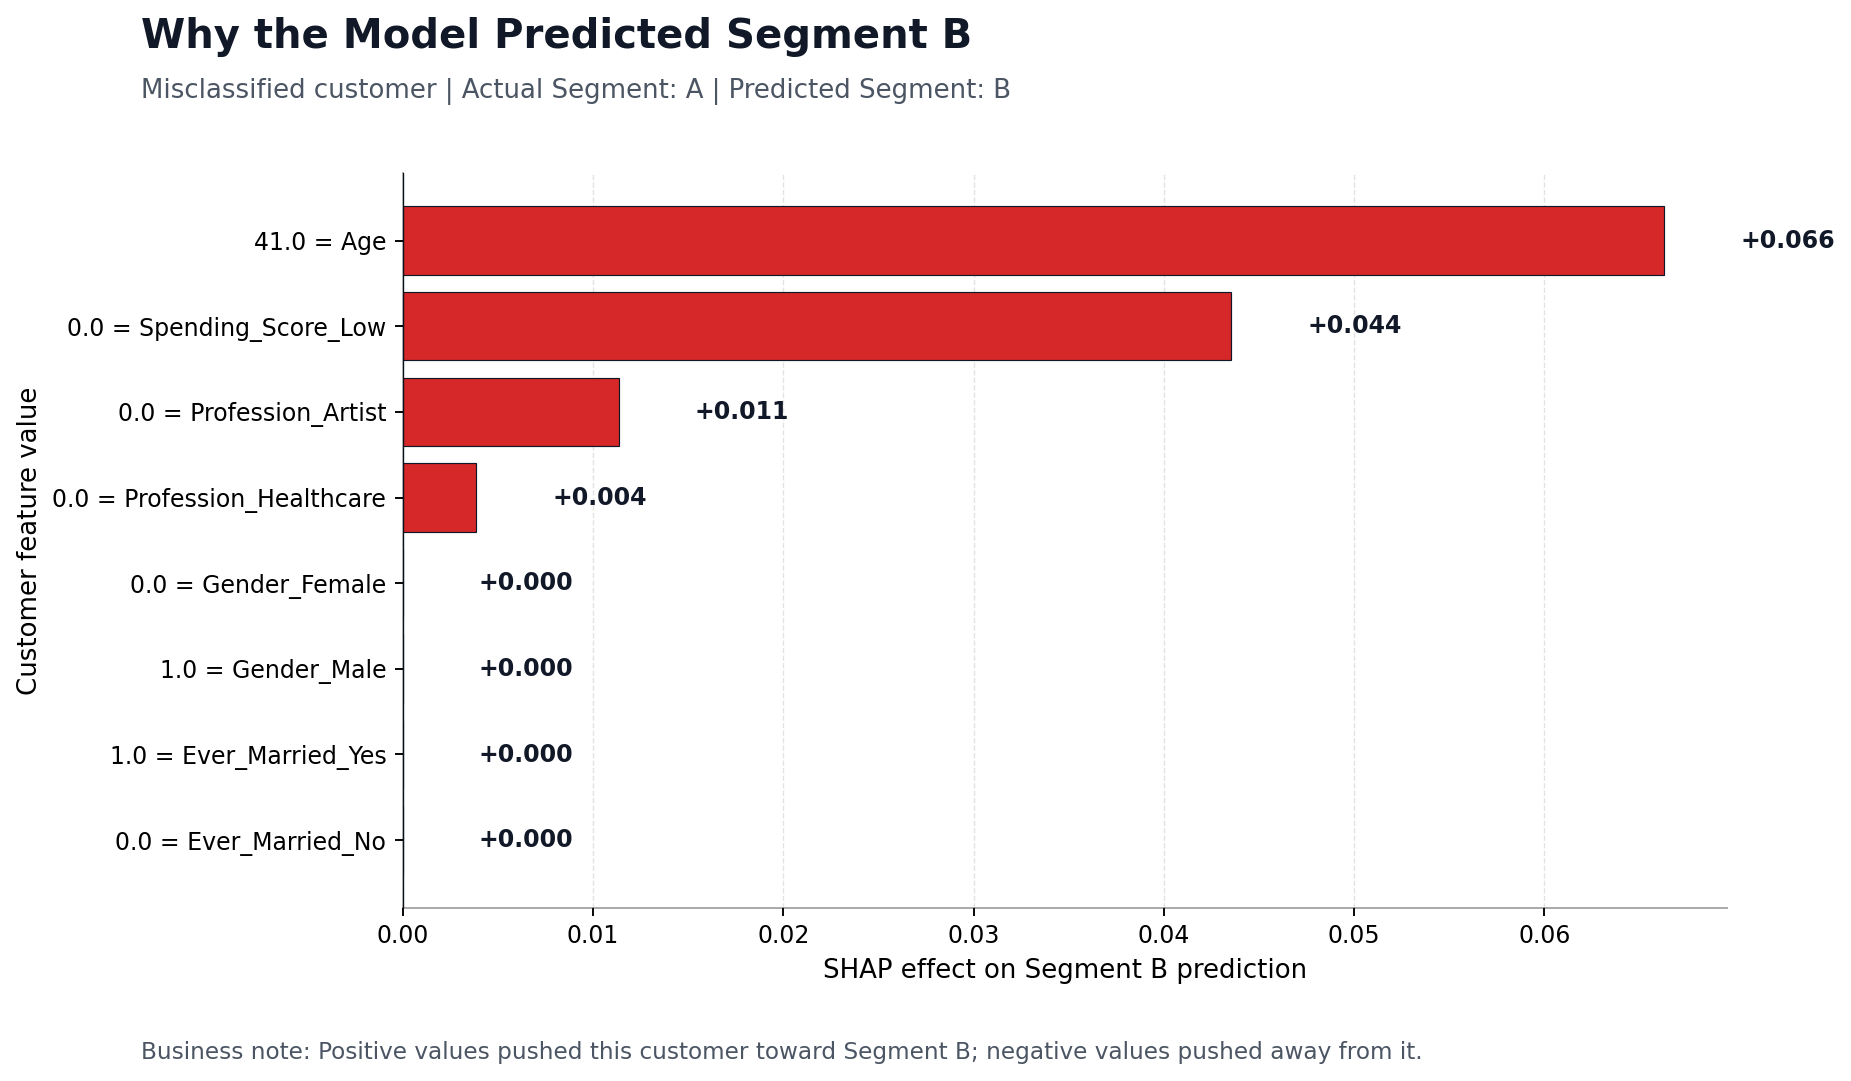

In [46]:
# Code Cell 11F: BI-Ready SHAP Waterfall for Misclassification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predicted segment -> class index.
# This makes the cell self-contained if it is run after the misclassification cell.
predicted_class_index = list(dt_gini.classes_).index(predicted_segment)

# Select the misclassified customer row.
misclassified_customer_df = X_test_shap_df.iloc[[misclassified_position]]

# Calculate SHAP values for this one customer.
misclassified_shap_values = tree_explainer(misclassified_customer_df)

# Get SHAP effects for the wrongly predicted class.
feature_names = misclassified_customer_df.columns
feature_values = misclassified_customer_df.iloc[0].values
shap_effects = misclassified_shap_values.values[0, :, predicted_class_index]

# Build a readable table.
waterfall_df = pd.DataFrame({
    "feature": feature_names,
    "customer_value": feature_values,
    "shap_effect": shap_effects
})

# Keep only strongest drivers.
top_waterfall_df = (
    waterfall_df
    .assign(abs_effect=lambda data: data["shap_effect"].abs())
    .sort_values("abs_effect", ascending=False)
    .head(8)
    .sort_values("shap_effect", ascending=True)
)

# Prepare labels with customer value included.
top_waterfall_df["feature_label"] = (
    top_waterfall_df["customer_value"].round(2).astype(str)
    + " = "
    + top_waterfall_df["feature"]
)

# Colors:
# Red means the feature pushed toward the predicted segment.
# Blue means the feature pushed away from the predicted segment.
bar_colors = np.where(
    top_waterfall_df["shap_effect"] >= 0,
    "#D62828",
    "#376795"
)

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=170)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.barh(
    top_waterfall_df["feature_label"],
    top_waterfall_df["shap_effect"],
    color=bar_colors,
    edgecolor="#111827",
    linewidth=0.5
)

# Add value labels at the end of each bar.
for bar in bars:
    width = bar.get_width()
    label_x = width + 0.004 if width >= 0 else width - 0.004
    ha = "left" if width >= 0 else "right"

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{width:+.3f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="semibold",
        color="#111827"
    )

# Zero reference line.
ax.axvline(0, color="#111827", linewidth=1)

# Title and subtitle with actual/predicted labels.
fig.text(
    0.08,
    0.95,
    f"Why the Model Predicted Segment {predicted_segment}",
    fontsize=17,
    fontweight="bold",
    ha="left",
    color="#111827"
)

fig.text(
    0.08,
    0.905,
    f"Misclassified customer | Actual Segment: {actual_segment} | Predicted Segment: {predicted_segment}",
    fontsize=11,
    ha="left",
    color="#4B5563"
)

# Axis formatting.
ax.set_xlabel(
    f"SHAP effect on Segment {predicted_segment} prediction",
    fontsize=11
)

ax.set_ylabel(
    "Customer feature value",
    fontsize=11
)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

# Business note.
fig.text(
    0.08,
    0.035,
    f"Business note: Positive values pushed this customer toward Segment {predicted_segment}; negative values pushed away from it.",
    fontsize=9.8,
    ha="left",
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.86])
plt.show()


### Misclassification Explanation

This chart explains why the model incorrectly predicted **Segment B** for a customer whose actual segment was **A**.

Positive SHAP effects pushed the prediction toward Segment B.  
Negative SHAP effects pushed the prediction away from Segment B.

The strongest driver was `Age`, followed by `Spending_Score_Low`.

This suggests the customer's profile looked similar to Segment B according to the model, even though the true label was Segment A.

## 12. Final Project Summary

### Project Objective

The goal of this project was to build and explain Decision Tree models for customer segmentation.

The target variable was:

`Segmentation`

The model tried to classify customers into four customer groups:

| Segment | Meaning |
|---|---|
| A | Customer segment A |
| B | Customer segment B |
| C | Customer segment C |
| D | Customer segment D |

---

### Dataset

The dataset contained customer demographic and behavioral features such as:

- age,
- gender,
- marital status,
- graduation status,
- profession,
- work experience,
- spending score,
- family size,
- anonymized customer category `Var_1`.

The target column was:

`Segmentation`

---

### Main Workflow

The project followed these steps:

1. Imported the customer segmentation dataset from Kaggle.
2. Loaded and inspected the training and test data.
3. Checked missing values.
4. Reviewed target class distribution.
5. Split features into numerical and categorical columns.
6. Built a preprocessing pipeline.
7. Created train and test sets.
8. Trained a baseline Decision Tree.
9. Visualized the Decision Tree.
10. Compared Gini and Entropy criteria.
11. Evaluated the model using accuracy, classification report, and confusion matrix.
12. Tested `min_samples_leaf` to study overfitting and underfitting.
13. Applied cost-complexity pruning using `ccp_alpha`.
14. Reviewed feature importance.
15. Compared standard Decision Tree with a custom Oblique Decision Tree.
16. Explained predictions using SHAP beeswarm and waterfall plots.

---

### Final Model Finding

The standard Gini Decision Tree performed better than the custom Oblique Decision Tree.

| Model | Test Accuracy | Interpretation |
|---|---:|---|
| Standard Decision Tree | 0.5105 | Better performance and easier to explain |
| Custom Oblique Tree | 0.4758 | More flexible, but weaker on this dataset |

The standard Decision Tree is the better model for this dataset because it is simpler, more interpretable, and gives stronger test accuracy.

## 12.2 Business Conclusion

### Main Business Insight

The Decision Tree model found that customer segmentation is mainly influenced by a small number of customer attributes.

The most important feature was:

`Age`

Other useful features included:

- `Profession_Artist`
- `Spending_Score_Low`
- `Profession_Healthcare`

---

### Segment D Insight

The SHAP explanation showed that Segment D is strongly linked to younger customers and low spending behavior.

Important findings for Segment D:

| Feature | Business Meaning |
|---|---|
| Lower `Age` | Pushes prediction toward Segment D |
| `Spending_Score_Low` | Pushes prediction toward Segment D |
| `Profession_Artist` | Pushes prediction away from Segment D |

This suggests that Segment D may represent younger, lower-spending customer profiles.

---

### Model Recommendation

The recommended model is the standard Gini Decision Tree.

#### Why?

| Reason | Explanation |
|---|---|
| Better accuracy | It performed better than the custom oblique tree |
| Better interpretability | Rules are easier to explain |
| Better visualization | Tree structure can be shown clearly |
| Better BI fit | Suitable for reporting and stakeholder explanation |

The custom Oblique Tree is useful for expert-level comparison, but it is not the best final model for this business problem.

---

### Final Recommendation

Use the standard Decision Tree as the explainable baseline model for customer segmentation.

For production-level performance, future work should compare this model with stronger algorithms such as:

- Random Forest,
- Gradient Boosting,
- XGBoost,
- LightGBM.

However, for explainability and learning Decision Tree concepts, the standard Decision Tree is the best final choice.

## 12.3 MVD Requirement Checklist

| Requirement | Status |
|---|---|
| Train `DecisionTreeClassifier(max_depth=3)` | Completed |
| Report train and test accuracy | Completed |
| Visualize the Decision Tree using `plot_tree` | Completed |
| Explain the root feature | Completed |
| Compare Gini vs Entropy | Completed |
| Test `min_samples_leaf` values 1, 5, 10, 20 | Completed |
| Plot train/test accuracy for `min_samples_leaf` | Completed |
| Explain overfitting and underfitting | Completed |
| Apply cost-complexity pruning with `ccp_alpha` | Completed |
| Create feature importance horizontal bar chart | Completed |
| Compare standard tree with oblique tree | Completed |
| Create SHAP summary beeswarm plot | Completed |
| Create SHAP waterfall plot for one misclassification | Completed |

All official Decision Tree MVD requirements were covered.

## Explanation

In this project, I built an explainable customer segmentation model using Decision Trees.

I started by preparing the dataset, handling missing values, encoding categorical features, and splitting the data into training and test sets.

I trained a baseline Decision Tree with `max_depth=3` to keep the model simple and interpretable.

The model achieved a test accuracy of around `0.51`.

I then compared Gini and Entropy splitting criteria.  
The Gini model performed slightly better, so I used it as the main baseline.

To study overfitting, I tested different `min_samples_leaf` values.  
The model with `min_samples_leaf=1` heavily overfit, while larger values created simpler and more stable trees.

I also applied cost-complexity pruning using `ccp_alpha`.  
Light pruning reduced model complexity while keeping test accuracy stable.

Feature importance showed that `Age` was the strongest driver of customer segmentation.

For the expert task, I compared the standard Decision Tree with a custom Oblique Decision Tree.  
The oblique tree used linear-combination splits, but it performed worse than the standard tree.

Finally, I used SHAP to explain the model globally and locally.  
The SHAP beeswarm plot showed the most important drivers for Segment D, and the waterfall plot explained why one customer was misclassified.

Overall, the standard Decision Tree was the best model for this task because it was more accurate, easier to explain, and more suitable for BI reporting.
